<h1 align="center">Too Remote to Be Local</h1>
<h3 align="center"><em>Latency Inflation in Anycast due to Remote Peering</em></h3>

[This repository](https://github.com/rhendriks/anycast-rp) contains the code and data for the [CNSM'25 paper]() "Too Remote to Be Local: Latency Inflation in Anycast due to Remote Peering".

# Code Contributors
* [Remi Hendriks](github.com/rhendriks)
* [Stefano Servillo](https://github.com/Stefano-25)
* [Savvas Kastanakis](https://github.com/kastanakis)

# imports and global variables (see requirements.txt for dependencies)

In [38]:
# !pip install -r requirements.txt

# Standard library
import os
import sys
import io
import time
import json
import gzip
import subprocess
import urllib.request
import urllib.error
import urllib.parse
from math import radians
from collections import Counter
import ipaddress

# Third-party libraries
import pandas as pd
import numpy as np
import duckdb
import requests
from bs4 import BeautifulSoup
import radix
from sklearn.neighbors import BallTree

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import geopandas as gpd
from shapely.geometry import Point

# matplotlib params
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams.update({'font.size': 20})


# constants
SPEED_IN_FIBRE = 299_792 / 1.467 # 1.467 refraction index fibre optics https://www.thorlabs.com/newgrouppage9.cfm?objectgroup_id=949
EARTH_RADIUS_KM = 6371 # Radius of Earth

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points.
    :param lat1: Latitude of first point.
    :param lon1: Longitude of first point.
    :param lat2: Latitude of second point.
    :param lon2: Longitude of second point.
    :return:
    """
    # Convert decimal degrees to radians
    lat1 = pd.to_numeric(lat1, errors='coerce')
    lon1 = pd.to_numeric(lon1, errors='coerce')
    lat2 = pd.to_numeric(lat2, errors='coerce')
    lon2 = pd.to_numeric(lon2, errors='coerce')

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    # Use arctan2 for numerical stability
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance_km = EARTH_RADIUS_KM * c
    return distance_km

# Read in data and combine with external datasets

In [3]:
traceroutes_df = pd.read_parquet('./data/traces.parquet', engine='pyarrow') # engine='fastparquet'

# filter out 1.0.0.0 as the parquet has 100+ traceroutes from each VP for this destination due to a measurement error
traceroutes_df = traceroutes_df[traceroutes_df['dst'] != '1.0.0.0']

traceroutes_df.head()

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl
5,aep3-ar.ark.caida.org,100.0.0.1,12,17,192.168.1.1,1,1.227,64
6,aep3-ar.ark.caida.org,100.0.0.1,12,17,192.168.0.1,2,1.485,63
7,aep3-ar.ark.caida.org,100.0.0.1,12,17,181.96.62.70,7,12.157,249
8,aep3-ar.ark.caida.org,100.0.0.1,12,17,195.22.220.58,8,10.412,248
9,aep3-ar.ark.caida.org,100.0.0.1,12,17,89.221.41.221,9,147.013,245


In [4]:
# drop hop_count, probe_count, hop_reply_ttl (we do not use these for our analysis)

traceroutes_df = traceroutes_df.drop(columns=['hop_count', 'probe_count', 'hop_reply_ttl'])

In [5]:
# # extract hop_name column for retrieving OI data
#
# unique_hop_addr = traceroutes_df['hop_addr'].dropna().unique()
# pd.DataFrame(unique_hop_addr).to_csv('./data/unique_hops.csv', index=False, header=False)


In [7]:
# add OpenINTEL PTR recrods to traceroute data

hop_names = pd.read_csv('./data/ptr_lookup.csv.gz')

traceroutes_df = pd.merge(traceroutes_df, hop_names, how='left', left_on='hop_addr', right_on='ip4_address')

# rename ptr_name to hop_name
traceroutes_df = traceroutes_df.rename(columns={'ptr_name': 'hop_name'})

In [8]:
# read in locations of Ark VPs
ark_locs = pd.read_csv('./data/arklocs.txt', header=None, names=['tx_hostname', 'vp_lat', 'vp_lon', 'tx_city', 'vp_asn'])
ark_locs['tx_hostname'] = ark_locs['tx_hostname'].str.split(".ark.caida.org").str[0]
ark_locs['vp_asn'] = ark_locs['vp_asn'].apply(lambda x: '-' if pd.isna(x) else str(int(float(x))))
ark_locs['tx_airport'] = ark_locs['tx_hostname'].str[:3]

ark_locs.head()

,tx_hostname,vp_lat,vp_lon,tx_city,vp_asn,tx_airport
0,hlz2-nz,-37.79,175.28,Hamilton,9500,hlz
1,hkg4-cn,22.36,114.12,Hong Kong,212238,hkg
2,lax4-us,33.92,-118.39,Los Angeles,212238,lax
3,bfi-us,47.61,-122.33,Seattle,209,bfi
4,drs-de,51.03,13.73,Dresden,680,drs


In [9]:
# add ark locations
traceroutes_df['tx_hostname'] = traceroutes_df['tx_hostname'].str.split(".ark.caida.org").str[0]
traceroutes_df = pd.merge(traceroutes_df, ark_locs, on='tx_hostname', how='left')

del ark_locs

traceroutes_df.head()

,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,vp_asn,tx_airport
0,aep3-ar,100.0.0.1,192.168.1.1,1,1.227,NaN,NaN,-34.6,-58.38,Buenos Aires,7303,aep
1,aep3-ar,100.0.0.1,192.168.0.1,2,1.485,NaN,NaN,-34.6,-58.38,Buenos Aires,7303,aep
2,aep3-ar,100.0.0.1,181.96.62.70,7,12.157,181.96.62.70,host70.181-96-62.telecom.net.ar.,-34.6,-58.38,Buenos Aires,7303,aep
3,aep3-ar,100.0.0.1,195.22.220.58,8,10.412,NaN,NaN,-34.6,-58.38,Buenos Aires,7303,aep
4,aep3-ar,100.0.0.1,89.221.41.221,9,147.013,NaN,NaN,-34.6,-58.38,Buenos Aires,7303,aep


# exploratory data analysis

In [10]:
# how many traceroutes?

len(traceroutes_df)

26717905

In [11]:
# how many VPs participated?

traceroutes_df['tx_hostname'].nunique()

274

In [12]:
# how many ASes are these in?

traceroutes_df['vp_asn'].nunique()

178

In [13]:
# how many targets did we measure?

traceroutes_df['dst'].nunique()

13734

In [14]:
# how many tx_hostname, dst pairs (i.e., how many traceroutes?)

traceroutes_df[['tx_hostname', 'dst']].drop_duplicates().shape[0]

3353799

In [15]:
# what is the average number of VPs that completed a traceroute towards a target

traceroutes_df.groupby('dst')['tx_hostname'].nunique().mean()


244.19681083442552

In [16]:
# what is the average number of hops captured?

traceroutes_df.groupby(['tx_hostname', 'dst']).size().mean()

7.966459826602608

In [17]:
# how many unique hop addresses?

traceroutes_df['hop_addr'].nunique()

99391

In [18]:
# how many unique hop addresses have PTR records?

traceroutes_df[~traceroutes_df['hop_name'].isna()]['hop_addr'].nunique()

45106

In [19]:
# how many hops have PTR records?

(~traceroutes_df['hop_name'].isna()).sum()

14131285

In [20]:
# how many hops do not have PTR records?

traceroutes_df['hop_name'].isna().sum()

12586620

In [21]:
 # how many unique PTR records did we observe?
traceroutes_df['hop_name'].nunique()

41758

# Calculate distances and RTTS

In [22]:
# get RTT to the PoP for each traceroute

dst_hops_df = traceroutes_df[traceroutes_df['dst'] == traceroutes_df['hop_addr']]

dst_hops_df = dst_hops_df[['tx_hostname', 'dst', 'hop_rtt']].rename(
    columns={'hop_rtt': 'pop_rtt'}
)
dst_hops_df = dst_hops_df.sort_values(by='pop_rtt').drop_duplicates(subset=['tx_hostname', 'dst']) # remove duplicate RTTs observed between an (Ark, PoP) pair -> keep the lowest RTT

traceroutes_df = pd.merge(traceroutes_df, dst_hops_df, on=['tx_hostname', 'dst'], how='left')

In [23]:
def rtt_to_distance(rtt_ms):
    one_way_time_s = (rtt_ms / 10_00) / 2  # to seconds and divide by 2 to get one-way latency
    distance_km = one_way_time_s * SPEED_IN_FIBRE
    return distance_km

In [24]:
# calculate distance between VP and hop
traceroutes_df['ark_to_hop'] = traceroutes_df['hop_rtt'].apply(rtt_to_distance)

# calculate distance between VP and PoP
traceroutes_df['ark_to_pop'] = traceroutes_df['pop_rtt'].apply(rtt_to_distance)

# calculate distance between hop and PoP
#traceroutes_df['hop_to_pop'] = np.maximum(0, result_df['ark_to_pop'] - result_df['ark_to_hop']) # this value is meaningless as the delta RTT between the two is unreliable

# identify bogon hops (['is_bogon'])


In [25]:
def ipv4_to_uint32(ip_str):
    """Converts an IPv4 string to an unsigned 32-bit integer."""
    if ip_str is None:
        return None
    try:
        # Convert to IPv4Address object first to validate
        ip_obj = ipaddress.ip_address(ip_str)
        if ip_obj.version == 4:
            return int(ip_obj) # Returns the integer representation
        else:
            return None # Not an IPv4 address
    except ValueError:
        # Handle cases where the string is not a valid IP address at all
        return None

In [27]:
# Get bogon list from Cymru https://www.team-cymru.com/bogon-networks

bogon_df = pd.read_csv('./data/2025-04-19.fullbogons-ipv4.csv')

bogon_ranges_cidr = bogon_df['Bogons'].tolist()

# create list of ranges
bogon_int_ranges = []
for cidr in bogon_ranges_cidr:
    network = ipaddress.ip_network(cidr, strict=False)
    start_int = int(network.network_address)
    end_int = int(network.broadcast_address)
    bogon_int_ranges.append((start_int, end_int))

del bogon_df

In [28]:
# create u32 of hop
ip_int_series = traceroutes_df['hop_addr'].apply(ipv4_to_uint32)

bogon_mask = pd.Series(False, index=ip_int_series.index)

for start_int, end_int in bogon_int_ranges:
    # Series.between is inclusive by default (both start and end)
    in_range_mask = ip_int_series.between(start_int, end_int, inclusive='both')
    bogon_mask |= in_range_mask  # Apply OR operation

traceroutes_df['hop_is_bogon'] = bogon_mask

del ip_int_series

traceroutes_df.head()

,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,vp_asn,tx_airport,pop_rtt,ark_to_hop,ark_to_pop,hop_is_bogon
0,aep3-ar,100.0.0.1,192.168.1.1,1,1.227,NaN,NaN,-34.6,-58.38,Buenos Aires,7303,aep,175.665,125.373137,17949.203027,True
1,aep3-ar,100.0.0.1,192.168.0.1,2,1.485,NaN,NaN,-34.6,-58.38,Buenos Aires,7303,aep,175.665,151.735215,17949.203027,True
2,aep3-ar,100.0.0.1,181.96.62.70,7,12.157,181.96.62.70,host70.181-96-62.telecom.net.ar.,-34.6,-58.38,Buenos Aires,7303,aep,175.665,1242.185189,17949.203027,False
3,aep3-ar,100.0.0.1,195.22.220.58,8,10.412,NaN,NaN,-34.6,-58.38,Buenos Aires,7303,aep,175.665,1063.883539,17949.203027,False
4,aep3-ar,100.0.0.1,89.221.41.221,9,147.013,NaN,NaN,-34.6,-58.38,Buenos Aires,7303,aep,175.665,15021.581900,17949.203027,False


# load in ipinfo data

In [29]:
# load in ipinfo data (weekly snapshots) (accessible through IPInfo)

# load data in duck DB
db_file = './data/ip_locations_ipv4.duckdb'
table_name = 'locations_ipv4'
json_file = './data/2025-03-31_standard_location.json.gz' # monthly snapshot

# if db_file exists, we are done
if os.path.exists(db_file):
    print(f"Database file {db_file} already exists. Skipping loading.")
else:
    print(f"Loading IPv4 ipinfo data from {json_file} into DuckDB table {table_name}")
    start_time = time.time()

    # create the database file
    con = duckdb.connect(database=db_file, read_only=False)

    # add ipv4 translation function to duckdb
    con.create_function('ipv4_to_uint32_udf', ipv4_to_uint32, [duckdb.typing.VARCHAR], duckdb.typing.UINTEGER)

    # create table schema
    con.execute(f"""
        DROP TABLE IF EXISTS {table_name};
        CREATE TABLE {table_name} (
            start_ip_str VARCHAR,
            end_ip_str VARCHAR,
            join_key VARCHAR,
            city VARCHAR,
            region VARCHAR,
            country VARCHAR,
            latitude DOUBLE,
            longitude DOUBLE,
            postal_code VARCHAR,
            timezone VARCHAR,
            start_ip_uint32 UINTEGER,
            end_ip_uint32 UINTEGER
        );
    """)

    # load in data (excluding ipv6 addresses)
    try:
        con.execute(f"""
            INSERT INTO {table_name} (
                start_ip_str, end_ip_str, join_key, city, region, country,
                latitude, longitude, postal_code, timezone,
                start_ip_uint32, end_ip_uint32
            )
            SELECT
                start_ip,
                end_ip,
                join_key,
                city,
                region,
                country,
                CAST(latitude AS DOUBLE),
                CAST(longitude AS DOUBLE),
                postal_code,
                timezone,
                ipv4_to_uint32_udf(start_ip) AS start_ip_u32,
                ipv4_to_uint32_udf(end_ip) AS end_ip_u32
            FROM read_json_auto('{json_file}', filename=true)
            WHERE
                -- filter out non-ipv4 addresses
                start_ip LIKE '%.%.%.%' AND start_ip NOT LIKE '%:%' AND
                end_ip LIKE '%.%.%.%'   AND end_ip   NOT LIKE '%:%'
        """)
    except Exception as e:
        print(f"An error occurred during INSERT: {e}")
        con.close()
        raise

    print("Creating index on IP ranges...")
    con.execute(f"CREATE INDEX ip_range_idx_u32 ON {table_name} (start_ip_uint32, end_ip_uint32);")
    con.close()

    end_time = time.time()
    print(f"IPInfo (IPV4) Database creation took: {end_time - start_time:.2f} seconds")

Loading IPv4 ipinfo data from ./data/2025-03-31_standard_location.json.gz into DuckDB table locations_ipv4


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Creating index on IP ranges...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IPInfo (IPV4) Database creation took: 294.64 seconds


In [30]:
# get unique non-bogon addresses
unique_addr = traceroutes_df[~traceroutes_df['hop_is_bogon']]['hop_addr'].dropna().unique()
print(f"Found {len(unique_addr)} unique hop addresses out of {len(traceroutes_df)} total hops.")

# get u32 values for lookup
addr_data = []
for hop in unique_addr:
    ip_uint32 = ipv4_to_uint32(hop)
    if ip_uint32 is not None: # Keep only valid IPv4 conversions
        addr_data.append({'hop_addr': hop, 'hop_addr_uint32': ip_uint32})

unique_addr_df = pd.DataFrame(addr_data)
unique_addr_df['hop_addr_uint32'] = unique_addr_df['hop_addr_uint32'].astype('uint32')

del unique_addr
del addr_data

Found 93110 unique hop addresses out of 26717905 total hops.


In [31]:
columns_to_load = [
    'city',
    'latitude',
    'longitude',
    'start_ip_uint32',
    'end_ip_uint32'
]
select_cols_str = ", ".join(columns_to_load)

dtypes_to_load = {
    'city': 'string',
    'latitude': 'float32',
    'longitude': 'float32',
    'start_ip_uint32': 'uint32',
    'end_ip_uint32': 'uint32'
}


print(f"Loading selected columns from {table_name} into Pandas...")
start_load_time = time.time()
con = None

try:
    con = duckdb.connect(database=db_file, read_only=True)
    print("  Connected to DuckDB.")

    # cast df
    select_expressions = []
    for col in columns_to_load:
        dtype = dtypes_to_load.get(col)
        if dtype:
            # data types
            sql_type = dtype.replace('string', 'VARCHAR') \
                            .replace('float32', 'FLOAT') \
                            .replace('float64', 'DOUBLE') \
                            .replace('uint32', 'UINTEGER') \
                            .replace('Int64', 'BIGINT')
            select_expressions.append(f"CAST({col} AS {sql_type}) AS {col}")
        else:
            select_expressions.append(col)

    select_query_cols_str = ",\n    ".join(select_expressions)

    query = f"""
    SELECT
        {select_query_cols_str}
    FROM {table_name}
    WHERE start_ip_uint32 IS NOT NULL -- exclude NaN values
    ORDER BY start_ip_uint32 ASC; -- sort by start_ip_uint32
    """

    ipinfo_df = con.execute(query).fetchdf()
    print(f"Successfully loaded {len(ipinfo_df)} rows.")

except Exception as e:
    print(f"An error occurred loading data from DuckDB: {e}")
finally:
    if con:
        con.close()
        print("  DuckDB connection closed.")

end_load_time = time.time()

print(f"\nLoading and initial sorting took: {end_load_time - start_load_time:.2f} seconds")
print("\nLoaded ip2location DataFrame Info:")
ipinfo_df.info(memory_usage='deep') # Check memory usage

Loading selected columns from locations_ipv4 into Pandas...
  Connected to DuckDB.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Successfully loaded 27274159 rows.
  DuckDB connection closed.

Loading and initial sorting took: 9.88 seconds

Loaded ip2location DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27274159 entries, 0 to 27274158
Data columns (total 5 columns):
 #   Column           Dtype  
---  ------           -----  
 0   city             object 
 1   latitude         float32
 2   longitude        float32
 3   start_ip_uint32  uint32 
 4   end_ip_uint32    uint32 
dtypes: float32(2), object(1), uint32(2)
memory usage: 2.1 GB


In [32]:
# unique hop addresses df

unique_addr_df = unique_addr_df.sort_values('hop_addr_uint32').reset_index(drop=True)

# add location information
unique_addr_df = pd.merge_asof(
    unique_addr_df,
    ipinfo_df,
    left_on='hop_addr_uint32',
    right_on='start_ip_uint32',
    direction='backward'
)

In [33]:
cols_to_merge = ['hop_addr', 'city', 'latitude', 'longitude']

# add location data to full dataset
traceroutes_df = pd.merge(
    traceroutes_df,
    unique_addr_df[cols_to_merge],
    on='hop_addr',
    how='left'
)

rename_map = {
    "city": "ipinfo_city",
    "latitude": "ipinfo_lat",
    "longitude": "ipinfo_lon"
}

traceroutes_df = traceroutes_df.rename(columns=rename_map)

In [34]:
# how many hops have IPInfo locations?

(~traceroutes_df['ipinfo_city'].isna()).sum()

23973174

In [35]:
# how many hops have no IPInfo locations (i.e., bogons)?

traceroutes_df['ipinfo_city'].isna().sum()

2744731

# PTR record translation (Hoiho)

In [38]:
# requires JSON:XS

# configuration files
ptr_records_file = './data/ptr_records.csv.gz'
hoiho_script = './data/hoiho/hoiho-apply.pl'
hoiho_db = './data/hoiho/2024-08.midar-iff.geo-re.jsonl.gz'

# store unique PTR records
print(f"\nSaving unique PTR records to {ptr_records_file}...")
traceroutes_df['hop_name'] = traceroutes_df['hop_name'].str.rstrip('.') # OI data has a trailing dot
unique_hop_names = traceroutes_df['hop_name'].unique()
pd.DataFrame(unique_hop_names).to_csv(ptr_records_file, index=False, header=False)
print(f"Saved {len(unique_hop_names)} unique names.")

process = False # flip to run perl script manually
if process:
    # Check if required files/scripts exist before running
    if not os.path.exists(hoiho_script):
         print(f"ERROR: Hoiho script not found at '{hoiho_script}'")
    elif not os.path.exists(hoiho_db):
         print(f"ERROR: Hoiho database not found at '{hoiho_db}'")
    elif not os.path.exists(ptr_records_file):
         print(f"ERROR: Input PTR file not found at '{ptr_records_file}'")
    else:
        print(f"\nExecuting Hoiho Perl script: {hoiho_script}...")
        command = f"cat {ptr_records_file} | perl {hoiho_script} {hoiho_db}"
        try:
            # run perl command
            process_result = subprocess.run(
                command,
                shell=True,
                capture_output=True,
                text=True,
                check=True
            )

            # Get the standard output from the completed process
            ptr_translations_content = process_result.stdout
            print(f"Perl script executed successfully. Output length: {len(ptr_translations_content)} chars.")

            # Check for errors printed to stderr
            if process_result.stderr:
                 print("\n--- Warnings/Errors from Perl script (stderr) ---")
                 print(process_result.stderr)
                 print("-------------------------------------------------")

            print("\nLoading PTR translations from script output...")
            if ptr_translations_content:
                ptr_map = pd.read_csv(
                    io.StringIO(ptr_translations_content),
                    sep=' ',
                    on_bad_lines='skip',
                    names=['hop_name', 'location', 'code', 'ptr_lat', 'ptr_lon', 'ptr_city'],
                    skipinitialspace=True
                )
                print(f"Loaded {len(ptr_map)} translation entries.")
            else:
                print("Warning: Perl script produced no output. PTR map will be empty.")
                ptr_map = pd.DataFrame(columns=['hop_name', 'location', 'code', 'ptr_lat', 'ptr_lon', 'ptr_city'])
                ptr_map.to_csv('./data/hoiho_translations.csv.gz', index=False)


        except FileNotFoundError:
            print(f"ERROR: 'perl' command not found. Is Perl installed and in your system's PATH?")
        except subprocess.CalledProcessError as e:
            print(f"ERROR: Perl script execution failed with exit code {e.returncode}.")
            print("--- Perl script STDOUT ---")
            print(e.stdout)
            print("--- Perl script STDERR ---")
            print(e.stderr)
        except Exception as e:
            print(f"An unexpected error occurred during subprocess execution: {e}")
else:
    # Read records (instead of running perl script)
    ptr_map = pd.read_csv('./data/hoiho_translations.csv.gz')

print("\nMerging PTR translations into final DataFrame...")
cols_to_merge = ['hop_name', 'ptr_lat', 'ptr_lon', 'ptr_city']

traceroutes_df = pd.merge(
    traceroutes_df,
    ptr_map[cols_to_merge],
    on='hop_name',
    how='left'
)
print("Merge complete.")


Saving unique PTR records to ./data/ptr_records.csv.gz...
Saved 41759 unique names.

Merging PTR translations into final DataFrame...
Merge complete.


In [39]:
# how many PTR records have a city location?

(~ptr_map['ptr_city'].isna()).sum()

16565

In [40]:
# how many PTR records have no city location?

ptr_map['ptr_city'].isna().sum()

3048

In [41]:
# how many hops have PTR city locations?

(~traceroutes_df['ptr_city'].isna()).sum()

3301373

In [42]:
# how many hops have NO PTR city locations?

(traceroutes_df['ptr_city'].isna()).sum()

23416532

# Validate hop locations

In [43]:
# loc_valid

# calculate distance between 'vp_lat', 'vp_lon' and 'latitude', 'longitude'
# verify distance is smaller than 'ark_to_hop' (which is in km)

### verify IPinfo locations
# calculate distance
traceroutes_df['calculated_distance_km'] = haversine(
    traceroutes_df['vp_lat'],
    traceroutes_df['vp_lon'],
    traceroutes_df['ipinfo_lat'],
    traceroutes_df['ipinfo_lon']
)


# distance between points must be less than the maximum distance travelled given the latency difference
traceroutes_df['ipinfo_loc_valid'] = traceroutes_df['calculated_distance_km'] < traceroutes_df['ark_to_hop']


### verify PTR record locations
traceroutes_df['calculated_distance_km'] = haversine(
    traceroutes_df['vp_lat'],
    traceroutes_df['vp_lon'],
    traceroutes_df['ptr_lat'],
    traceroutes_df['ptr_lon']
)

traceroutes_df['ptr_loc_valid'] = traceroutes_df['calculated_distance_km'] < traceroutes_df['ark_to_hop']

traceroutes_df.drop(columns=['calculated_distance_km'], inplace=True)

# ptr valids

valid_count = traceroutes_df['ptr_loc_valid'].sum()
total_count = (~traceroutes_df['ptr_city'].isna()).sum()

print(f"PTR locations {valid_count} valid out of {total_count}")

# ipinfo valids

valid_count = traceroutes_df['ipinfo_loc_valid'].sum()
total_count = (~traceroutes_df['ipinfo_city'].isna()).sum()

print(f"IPInfo locations {valid_count} valid out of {total_count}")

either_valid = (traceroutes_df['ptr_loc_valid'] | traceroutes_df['ipinfo_loc_valid']).sum()
print(f"Locations with either PTR or IPInfo valid locations: {either_valid}")

neither_valid = (~traceroutes_df['ptr_loc_valid'] & ~traceroutes_df['ipinfo_loc_valid']).sum()
print(f"Locations with neither PTR nor IPInfo valid locations: {neither_valid}")

PTR locations 3243374 valid out of 3301373
IPInfo locations 20374390 valid out of 23973174
Locations with either PTR or IPInfo valid locations: 20454038
Locations with neither PTR nor IPInfo valid locations: 6263867


In [44]:
# performing global invalidation

invalid_ipinfo_ips = set(
    traceroutes_df.loc[traceroutes_df['ipinfo_loc_valid'] == False, 'hop_addr'].unique()
)
invalid_ptr_ips = set(
    traceroutes_df.loc[traceroutes_df['ptr_loc_valid'] == False, 'hop_addr'].unique()
)

original_ipinfo_valid_count = traceroutes_df['ipinfo_loc_valid'].sum()
traceroutes_df.loc[traceroutes_df['hop_addr'].isin(invalid_ipinfo_ips), 'ipinfo_loc_valid'] = False
new_ipinfo_valid_count = traceroutes_df['ipinfo_loc_valid'].sum()

original_ptr_valid_count = traceroutes_df['ptr_loc_valid'].sum()
traceroutes_df.loc[traceroutes_df['hop_addr'].isin(invalid_ptr_ips), 'ptr_loc_valid'] = False
new_ptr_valid_count = traceroutes_df['ptr_loc_valid'].sum()

print(f"Global invalidation changed {original_ipinfo_valid_count - new_ipinfo_valid_count} IPInfo locations from valid to invalid.")
print(f"Global invalidation changed {original_ptr_valid_count - new_ptr_valid_count} PTR locations from valid to invalid.")

Global invalidation changed 1496390 IPInfo locations from valid to invalid.
Global invalidation changed 35576 PTR locations from valid to invalid.


In [45]:
# ptr valids

valid_count = traceroutes_df['ptr_loc_valid'].sum()
total_count = (~traceroutes_df['ptr_city'].isna()).sum()

print(f"PTR locations {valid_count} valid out of {total_count}")

# ipinfo valids

valid_count = traceroutes_df['ipinfo_loc_valid'].sum()
total_count = (~traceroutes_df['ipinfo_city'].isna()).sum()

print(f"IPInfo locations {valid_count} valid out of {total_count}")

either_valid = (traceroutes_df['ptr_loc_valid'] | traceroutes_df['ipinfo_loc_valid']).sum()
print(f"Locations with either PTR or IPInfo valid locations: {either_valid}")

neither_valid = (~traceroutes_df['ptr_loc_valid'] & ~traceroutes_df['ipinfo_loc_valid']).sum()
print(f"Locations with neither PTR nor IPInfo valid locations: {neither_valid}")

PTR locations 3207798 valid out of 3301373
IPInfo locations 18878000 valid out of 23973174
Locations with either PTR or IPInfo valid locations: 18962816
Locations with neither PTR nor IPInfo valid locations: 7755089


In [46]:
valid_count = traceroutes_df[traceroutes_df['ptr_loc_valid']]['hop_addr'].nunique()
total_count = traceroutes_df[(~traceroutes_df['ptr_city'].isna())]['hop_addr'].nunique()

print(f"Unique hops with PTR record inferred locations: {total_count} of which {valid_count} are valid")

# ipinfo valids

valid_count = traceroutes_df[traceroutes_df['ipinfo_loc_valid']]['hop_addr'].nunique()
total_count = traceroutes_df[(~traceroutes_df['ipinfo_city'].isna())]['hop_addr'].nunique()

print(f"Unique hops with IPinfo locations: {total_count} of which {valid_count} are valid")

either_valid = traceroutes_df[(traceroutes_df['ptr_loc_valid'] | traceroutes_df['ipinfo_loc_valid'])]['hop_addr'].nunique()
print(f"Unique hops with either PTR or IPInfo valid locations: {either_valid}")

both_invalid = traceroutes_df[((traceroutes_df['ptr_loc_valid'] == False) & (traceroutes_df['ipinfo_loc_valid'] == False))]['hop_addr'].nunique()
print(f"Unique hops with neither PTR nor IPInfo valid locations: {both_invalid}")

Unique hops with PTR record inferred locations: 16974 of which 16734 are valid
Unique hops with IPinfo locations: 93110 of which 74469 are valid
Unique hops with either PTR or IPInfo valid locations: 74876
Unique hops with neither PTR nor IPInfo valid locations: 24515


In [47]:
# get preferred locations (ptr if valid, else ipinfo if valid, else NaN)

conditions = [
    traceroutes_df['ptr_loc_valid'] == True,
    traceroutes_df['ipinfo_loc_valid'] == True
]

# For hop_city
city_choices = [
    traceroutes_df['ptr_city'],
    traceroutes_df['ipinfo_city']
]
# For hop_lat
lat_choices = [
    traceroutes_df['ptr_lat'],
    traceroutes_df['ipinfo_lat']
]

lon_choices = [
    traceroutes_df['ptr_lon'],
    traceroutes_df['ipinfo_lon']
]

# get hop location info
traceroutes_df['hop_city'] = np.select(conditions, city_choices, default=pd.NA)
traceroutes_df['hop_lat'] = np.select(conditions, lat_choices, default=np.nan)
traceroutes_df['hop_lon'] = np.select(conditions, lon_choices, default=np.nan)

traceroutes_df = traceroutes_df.drop(columns=
    [
        'ipinfo_city', 'ipinfo_lat', 'ipinfo_lon',
        'ptr_city', 'ptr_lat', 'ptr_lon',
        'ptr_loc_valid', 'ipinfo_loc_valid'
    ]
)

print(f"no locations available {(traceroutes_df['hop_city'].isna()).sum()}")
print(f"locations available {(~traceroutes_df['hop_city'].isna()).sum()}")



no locations available 7755101
locations available 18962804


In [48]:
# target addresses are anycast, where we cannot trust geolocation data

traceroutes_df.loc[
    traceroutes_df['hop_addr'] == traceroutes_df['dst'],
    ['hop_lat', 'hop_lon']
] = np.nan

traceroutes_df.loc[
    traceroutes_df['hop_addr'] == traceroutes_df['dst'],
    ['hop_city']
] = 'ANYCAST'

In [49]:
# convert city formats (Zürich -> Zurich) for consistency between Hoiho and IPInfo
traceroutes_df['hop_city'] = (
    traceroutes_df['hop_city']
    .str.normalize('NFD')
    .str.encode('ascii', 'ignore')
    .str.decode('utf-8')
    .str.lower()
)

# add USN regions

In [51]:
# load in region data
un_regions_df = pd.read_csv('./data/unsd_geography.csv', sep=';')
# We only need the code and the region names
un_regions_df = un_regions_df[['ISO-alpha3 Code', 'Region Name', 'Sub-region Name']]

un_regions_df.head()

,ISO-alpha3 Code,Region Name,Sub-region Name
0,DZA,Africa,Northern Africa
1,EGY,Africa,Northern Africa
2,LBY,Africa,Northern Africa
3,MAR,Africa,Northern Africa
4,SDN,Africa,Northern Africa


In [52]:
# get world map using geopandas (converting coordinates to country)

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
# We only need the country's ISO code and its geometric shape.
world = world[['ISO_A3', 'geometry']]

world.head()

,ISO_A3,geometry
0,FJI,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,TZA,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,ESH,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,CAN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,USA,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [53]:
# create lookup map (converting coordinates to UNSD region)
world_with_regions = world.merge(
    un_regions_df,
    left_on='ISO_A3',
    right_on='ISO-alpha3 Code',
    how='left'
)

world_with_regions.head()

,ISO_A3,geometry,ISO-alpha3 Code,Region Name,Sub-region Name
0,FJI,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",FJI,Oceania,Melanesia
1,TZA,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",TZA,Africa,Sub-Saharan Africa
2,ESH,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",ESH,Africa,Northern Africa
3,CAN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",CAN,Americas,Northern America
4,USA,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",USA,Americas,Northern America


In [54]:
# create geo dataframe for our coordinates

geometry = [Point(xy) for xy in zip(traceroutes_df['hop_lon'], traceroutes_df['hop_lat'])]
traceroutes_gdf = gpd.GeoDataFrame(
    traceroutes_df,
    crs="EPSG:4326",  # WGS84 is the standard for GPS coordinates
    geometry=geometry
)

In [55]:
# perform lookup (converting coordinates to country)

points_with_regions = gpd.sjoin(
    traceroutes_gdf,
    world_with_regions,
    how="left",
    predicate="within"
)

points_with_regions.head()


,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,...,hop_is_bogon,hop_city,hop_lat,hop_lon,geometry,index_right,ISO_A3,ISO-alpha3 Code,Region Name,Sub-region Name
0,aep3-ar,100.0.0.1,192.168.1.1,1,1.227,NaN,NaN,-34.6,-58.38,Buenos Aires,...,True,<NA>,NaN,NaN,POINT EMPTY,NaN,NaN,NaN,NaN,NaN
1,aep3-ar,100.0.0.1,192.168.0.1,2,1.485,NaN,NaN,-34.6,-58.38,Buenos Aires,...,True,<NA>,NaN,NaN,POINT EMPTY,NaN,NaN,NaN,NaN,NaN
2,aep3-ar,100.0.0.1,181.96.62.70,7,12.157,181.96.62.70,host70.181-96-62.telecom.net.ar,-34.6,-58.38,Buenos Aires,...,False,buenos aires,-34.613152,-58.377232,POINT (-58.37723 -34.61315),9.0,ARG,ARG,Americas,Latin America and the Caribbean
3,aep3-ar,100.0.0.1,195.22.220.58,8,10.412,NaN,NaN,-34.6,-58.38,Buenos Aires,...,False,buenos aires,-34.613152,-58.377232,POINT (-58.37723 -34.61315),9.0,ARG,ARG,Americas,Latin America and the Caribbean
4,aep3-ar,100.0.0.1,89.221.41.221,9,147.013,NaN,NaN,-34.6,-58.38,Buenos Aires,...,False,miami,25.774269,-80.193657,POINT (-80.19366 25.77427),4.0,USA,USA,Americas,Northern America


In [56]:
# rename results

traceroutes_df = points_with_regions.rename(columns={
    'Region Name': 'hop_region',
    'Sub-region Name': 'hop_sub_region',
    'ISO_A3': 'hop_country_code',
}).drop(columns=['ISO-alpha3 Code', 'index_right', 'geometry'])

del points_with_regions


traceroutes_df.head()

,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,...,pop_rtt,ark_to_hop,ark_to_pop,hop_is_bogon,hop_city,hop_lat,hop_lon,hop_country_code,hop_region,hop_sub_region
0,aep3-ar,100.0.0.1,192.168.1.1,1,1.227,NaN,NaN,-34.6,-58.38,Buenos Aires,...,175.665,125.373137,17949.203027,True,<NA>,NaN,NaN,NaN,NaN,NaN
1,aep3-ar,100.0.0.1,192.168.0.1,2,1.485,NaN,NaN,-34.6,-58.38,Buenos Aires,...,175.665,151.735215,17949.203027,True,<NA>,NaN,NaN,NaN,NaN,NaN
2,aep3-ar,100.0.0.1,181.96.62.70,7,12.157,181.96.62.70,host70.181-96-62.telecom.net.ar,-34.6,-58.38,Buenos Aires,...,175.665,1242.185189,17949.203027,False,buenos aires,-34.613152,-58.377232,ARG,Americas,Latin America and the Caribbean
3,aep3-ar,100.0.0.1,195.22.220.58,8,10.412,NaN,NaN,-34.6,-58.38,Buenos Aires,...,175.665,1063.883539,17949.203027,False,buenos aires,-34.613152,-58.377232,ARG,Americas,Latin America and the Caribbean
4,aep3-ar,100.0.0.1,89.221.41.221,9,147.013,NaN,NaN,-34.6,-58.38,Buenos Aires,...,175.665,15021.581900,17949.203027,False,miami,25.774269,-80.193657,USA,Americas,Northern America


# Get ASN data

In [57]:
def find_day_url_v4():
    #https://data.caida.org/datasets/routing/routeviews-prefix2as/2025/04/routeviews-rv2-20250418-1200.pfx2as.gz
    base_url = 'http://data.caida.org/datasets/routing/routeviews-prefix2as/{}/{:02d}'.format(2025, 4)
    daymask = '{}{:02d}{:02d}'.format(2025, 4, 19)
    dayurl = None
    try:
        page = requests.get(base_url, timeout=10).text
        soup = BeautifulSoup(page, 'html.parser')
        for node in soup.find_all('a'):
            href = node.get('href')
            if href and href.endswith('pfx2as.gz'):
                find_dayurl = f"{base_url}/{href}" # Construct full URL
                if daymask in find_dayurl:
                    dayurl = find_dayurl
                    break
    except requests.exceptions.RequestException as e:
        print(f"Error fetching CAIDA directory page {base_url}: {e}")
        sys.exit(99)

    if dayurl is None:
        print('Unable to find day-specific URL for {}'.format(base_url))
        sys.exit(99)
    return dayurl

In [58]:
# adds ASN and BGP prefix from CAIDA data to a csv with ipaddresses
def fetch_caida_data_as_radix():
    caida_url = find_day_url_v4()
    caida_radix = radix.Radix()

    try:
        sys.stdout.write('Retrieving {} ... '.format(caida_url))
        sys.stdout.flush()

        response = urllib.request.urlopen(caida_url)
        gzFile = io.BytesIO()
        gzFile.write(response.read())

        print('OK')
    except os.error as err:
        print('Failed to download or parse {}'.format(caida_url))
        print(err)
        sys.exit(99)

    gzFile.seek(0, os.SEEK_END)
    print('Read {} bytes of compressed data'.format(gzFile.tell()))
    gzFile.seek(0, os.SEEK_SET)

    # Iterate over decompressed content
    pfx2as = gzip.GzipFile(fileobj=gzFile, mode='rb')

    pfx_count = 0

    for line in pfx2as:
        line = line.decode('utf-8')

        line = line.rstrip('\n')

        caida_vals = line.split('\t')

        if len(caida_vals) != 3:
            print('Invalid line in data retrieved from CAIDA ({})'.format(line))

        prefix = '{}/{}'.format(caida_vals[0], caida_vals[1])
        asn = caida_vals[2]


        rnode = caida_radix.add(prefix)
        rnode.data["AS"] = asn

        pfx_count += 1

        if (pfx_count % 100000) == 0:
            sys.stdout.write('+')
            sys.stdout.flush()
        elif (pfx_count % 10000) == 0:
            sys.stdout.write('-')
            sys.stdout.flush()

    pfx2as.close()

    print()
    print('Processed {} prefixes'.format(pfx_count))

    return caida_radix

In [59]:
def lookup_asn(ip, lookup_radix4):
    try:
        rnode = lookup_radix4.search_best(ip)
        if rnode:
            return rnode.data.get('AS', '-')
        else:
            return '-' # not found
    except Exception:
        print(f"Radix lookup failed for invalid IP format: {ip}")
        return '-' # invalid

In [62]:
# add missing ASNs using peeringdb

with gzip.open('data/caida/peeringdb_2_dump_2025_04_20.json.gz', 'rt', encoding='utf-8') as gzipped_file:
    data = json.load(gzipped_file)

asn_ixp=[]

for i in data['netixlan']['data']:
    asn=i['asn']
    name=i['name']
    address=i['ipaddr4']
    asn_ixp.append((asn,name,address))

asn_ixp=pd.DataFrame(asn_ixp, columns=['asn', 'pop', 'addr'])

# convert ASN to string
asn_ixp['asn'] = asn_ixp['asn'].astype(str)
asn_ixp['asn'].str.replace(',', '_')

asn_ixp.head()

,asn,pop,addr
0,8075,Equinix New York,198.32.118.91
1,20940,SIX Seattle: MTU 1500,206.81.80.113
2,20940,MegaIX Munich,194.59.190.59
3,31800,NL-ix: Main,193.239.116.162
4,31800,Equinix Dallas,206.223.118.88


In [63]:
print(f"\nFound {len(unique_addr_df)} unique non-null IP strings to look up.") # unique hop addresses, excluding bogons


if 'lookup_radix4' not in locals():
    lookup_radix4 = fetch_caida_data_as_radix()

# perform lookup
print(f"\nPerforming {len(unique_addr_df)} lookups in Radix tree...")

unique_addr_df['hop_asn'] = unique_addr_df['hop_addr'].apply(
    lambda ip: lookup_asn(ip, lookup_radix4)
)


### add failed lookups using peeringdb
unique_addr_df['hop_asn'].fillna('-', inplace=True)
unique_addr_df = pd.merge(unique_addr_df, asn_ixp, left_on='hop_addr', right_on='addr', how='left')

traceroutes_df = pd.merge(
    traceroutes_df,
    unique_addr_df[['hop_addr', 'hop_asn']],
    on='hop_addr',
    how='left'
)

# unknown ASes have value '-'
traceroutes_df['hop_asn'].fillna('-', inplace=True)
print("Merge complete.")

traceroutes_df.head()


Found 93110 unique non-null IP strings to look up.
Retrieving http://data.caida.org/datasets/routing/routeviews-prefix2as/2025/04/routeviews-rv2-20250419-0800.pfx2as.gz ... OK
Read 3585254 bytes of compressed data
---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---
Processed 1035774 prefixes

Performing 93110 lookups in Radix tree...


/var/folders/k_/b2zc8kg571bcqh2l9j8mj82h0000gn/T/ipykernel_9821/302428949.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  unique_addr_df['hop_asn'].fillna('-', inplace=True)
/var/folders/k_/b2zc8kg571bcqh2l9j8mj82h0000gn/T/ipykernel_9821/302428949.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

Merge complete.


,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,...,ark_to_hop,ark_to_pop,hop_is_bogon,hop_city,hop_lat,hop_lon,hop_country_code,hop_region,hop_sub_region,hop_asn
0,aep3-ar,100.0.0.1,192.168.1.1,1,1.227,NaN,NaN,-34.6,-58.38,Buenos Aires,...,125.373137,17949.203027,True,<NA>,NaN,NaN,NaN,NaN,NaN,-
1,aep3-ar,100.0.0.1,192.168.0.1,2,1.485,NaN,NaN,-34.6,-58.38,Buenos Aires,...,151.735215,17949.203027,True,<NA>,NaN,NaN,NaN,NaN,NaN,-
2,aep3-ar,100.0.0.1,181.96.62.70,7,12.157,181.96.62.70,host70.181-96-62.telecom.net.ar,-34.6,-58.38,Buenos Aires,...,1242.185189,17949.203027,False,buenos aires,-34.613152,-58.377232,ARG,Americas,Latin America and the Caribbean,7303
3,aep3-ar,100.0.0.1,195.22.220.58,8,10.412,NaN,NaN,-34.6,-58.38,Buenos Aires,...,1063.883539,17949.203027,False,buenos aires,-34.613152,-58.377232,ARG,Americas,Latin America and the Caribbean,6762
4,aep3-ar,100.0.0.1,89.221.41.221,9,147.013,NaN,NaN,-34.6,-58.38,Buenos Aires,...,15021.581900,17949.203027,False,miami,25.774269,-80.193657,USA,Americas,Northern America,6762


In [64]:
# how many ASes in the dataset?

traceroutes_df['hop_asn'].nunique()

1828

In [65]:
traceroutes_df[traceroutes_df['hop_asn'].str.contains('_')].count() # 209k hops are inside MOAses

tx_hostname         208587
dst                 208587
hop_addr            208587
hop_probe_ttl       208587
hop_rtt             208587
ip4_address         164956
hop_name            164956
vp_lat              208587
vp_lon              208587
tx_city             208587
vp_asn              208587
tx_airport          208587
pop_rtt             208587
ark_to_hop          208587
ark_to_pop          208587
hop_is_bogon        208587
hop_city            207478
hop_lat             139297
hop_lon             139297
hop_country_code    139297
hop_region          138624
hop_sub_region      138624
hop_asn             208587
dtype: int64

In [66]:
# add anycast destination ASN
unique_dsts = traceroutes_df['dst'].unique()

asn_lookup_df = pd.DataFrame({
    'dst': unique_dsts,
    'dst_asn': [lookup_asn(ip, lookup_radix4) for ip in unique_dsts]
})

traceroutes_df = traceroutes_df.merge(asn_lookup_df, on='dst', how='left')

del unique_dsts
del asn_lookup_df

# Calculate distances between hops

In [67]:
# drop hops with no locations
traceroutes_with_geolocs_df = traceroutes_df[
    traceroutes_df['hop_lat'].notna() & traceroutes_df['hop_lon'].notna()
].copy()

# sort by trace and TTL
traceroutes_with_geolocs_df = traceroutes_with_geolocs_df.sort_values(
    by=['tx_hostname', 'dst', 'hop_probe_ttl']
)

# for each trace we calculate the inter-hop distances
grouped_geoloc_traces = traceroutes_with_geolocs_df.groupby(['tx_hostname', 'dst'])

# get the lat,lon of the next hop
traceroutes_with_geolocs_df['next_geoloc_hop_lat'] = grouped_geoloc_traces['hop_lat'].shift(-1)
traceroutes_with_geolocs_df['next_geoloc_hop_lon'] = grouped_geoloc_traces['hop_lon'].shift(-1)

# join with all hop data
traceroutes_df = traceroutes_df.join(
    traceroutes_with_geolocs_df[['next_geoloc_hop_lat', 'next_geoloc_hop_lon']]
)

# calculate distance between current hop and the next hop with geolocation data
def calculate_distance_to_next_geoloc_hop(row):
    current_lat = row['hop_lat']
    current_lon = row['hop_lon']

    next_geoloc_lat = row['next_geoloc_hop_lat']
    next_geoloc_lon = row['next_geoloc_hop_lon']

    # Only calculate if the current hop has coordinates AND
    # we found a subsequent hop with coordinates for it.
    if pd.notna(current_lat) and pd.notna(current_lon) and \
       pd.notna(next_geoloc_lat) and pd.notna(next_geoloc_lon):
        return haversine(current_lat, current_lon, next_geoloc_lat, next_geoloc_lon)
    return np.nan

traceroutes_df['distance_to_next_geoloc_hop_km'] = traceroutes_df.apply(
    calculate_distance_to_next_geoloc_hop, axis=1
)

# drop temp columns
columns_to_drop = ['next_geoloc_hop_lat', 'next_geoloc_hop_lon']
traceroutes_df = traceroutes_df.drop(columns=columns_to_drop)

traceroutes_df.head()

,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,...,hop_is_bogon,hop_city,hop_lat,hop_lon,hop_country_code,hop_region,hop_sub_region,hop_asn,dst_asn,distance_to_next_geoloc_hop_km
0,aep3-ar,100.0.0.1,192.168.1.1,1,1.227,NaN,NaN,-34.6,-58.38,Buenos Aires,...,True,<NA>,NaN,NaN,NaN,NaN,NaN,-,701,NaN
1,aep3-ar,100.0.0.1,192.168.0.1,2,1.485,NaN,NaN,-34.6,-58.38,Buenos Aires,...,True,<NA>,NaN,NaN,NaN,NaN,NaN,-,701,NaN
2,aep3-ar,100.0.0.1,181.96.62.70,7,12.157,181.96.62.70,host70.181-96-62.telecom.net.ar,-34.6,-58.38,Buenos Aires,...,False,buenos aires,-34.613152,-58.377232,ARG,Americas,Latin America and the Caribbean,7303,701,0.000000
3,aep3-ar,100.0.0.1,195.22.220.58,8,10.412,NaN,NaN,-34.6,-58.38,Buenos Aires,...,False,buenos aires,-34.613152,-58.377232,ARG,Americas,Latin America and the Caribbean,6762,701,7097.454053
4,aep3-ar,100.0.0.1,89.221.41.221,9,147.013,NaN,NaN,-34.6,-58.38,Buenos Aires,...,False,miami,25.774269,-80.193657,USA,Americas,Northern America,6762,701,0.000000


# Get the inferred location of the anycast site reached (using the penultimate hop's location)

In [68]:
# get the p-hops (from which we infer the site reached)

p_hops = traceroutes_df[traceroutes_df['dst'] != traceroutes_df['hop_addr']].sort_values(by='hop_probe_ttl', ascending=False)\
                    .drop_duplicates(subset=['tx_hostname', 'dst'], keep='first')

p_hops.head()

,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,...,hop_is_bogon,hop_city,hop_lat,hop_lon,hop_country_code,hop_region,hop_sub_region,hop_asn,dst_asn,distance_to_next_geoloc_hop_km
3810728,hkg5-cn,23.11.40.7,23.40.189.1,43,453.065,23.40.189.1,vlan100.r01.tor01.hkg01.fab.netarch.akamai.com,22.32,114.22,Hong Kong,...,False,hong kong,22.320304,114.198074,CHN,Asia,Eastern Asia,20940,33905,NaN
18836613,puw-us,23.11.40.7,23.203.145.249,43,289.470,23.203.145.249,ae34.r03.border101.sea01.fab.netarch.akamai.com,46.73,-117.00,Moscow,...,False,seattle,47.449001,-122.308998,USA,Americas,Northern America,20940,33905,NaN
16070816,bed-us,23.11.38.17,23.198.9.65,38,340.269,23.198.9.65,vlan100.r05.tor01.bos01.fab.netarch.akamai.com,42.46,-71.35,Concord,...,False,boston,42.364300,-71.005203,USA,Americas,Northern America,20940,33905,NaN
2460881,ind-us,23.11.38.17,154.24.97.54,37,462.866,NaN,NaN,39.77,-86.16,Indianapolis,...,False,indianapolis,39.768379,-86.158043,USA,Americas,Northern America,174,33905,NaN
19281608,cpv-br,23.11.38.17,23.32.63.57,37,590.487,23.32.63.57,ae4.r01.gru01.icn.netarch.akamai.com,-7.23,-35.88,Campina Grande,...,False,sao paulo,-23.435556,-46.473057,BRA,Americas,Latin America and the Caribbean,20940,33905,NaN


In [69]:
# calculate distance between phop and VP coordinates

def calculate_haversine_for_row(row):
    # Extract coordinates from the row
    vp_coords = (row['vp_lat'], row['vp_lon'])
    reached_coords = (row['hop_lat'], row['hop_lon'])

    # Check for NaN values in any of the coordinates
    if pd.isna(vp_coords[0]) or pd.isna(vp_coords[1]) or \
       pd.isna(reached_coords[0]) or pd.isna(reached_coords[1]):
        return np.nan # Return NaN if any coordinate is missing

    distance = haversine(vp_coords[0], vp_coords[1], reached_coords[0], reached_coords[1])
    return distance

p_hops['dist_to_phop'] = p_hops.apply(calculate_haversine_for_row, axis=1)

In [70]:
# how many p-hops do we have?

print(f"Number of p-hops {len(p_hops)}")

Number of p-hops 3349745


In [71]:
# how many have city information

print(f"number of phops with city information {len(p_hops[~p_hops['hop_city'].isna()])}")
print(f"number of phops with no city information {len(p_hops[p_hops['hop_city'].isna()])}")


number of phops with city information 3157078
number of phops with no city information 192667


In [72]:
# merge data into traceroutes_df as reached_city, reached_lon, reached_lat

p_hops_renamed = p_hops[['tx_hostname', 'dst', 'hop_city', 'hop_lat', 'hop_lon', 'dist_to_phop']].rename(columns={
    'hop_city': 'reached_city',
    'hop_lat': 'reached_lat',
    'hop_lon': 'reached_lon',
    'dist_to_phop': 'dist_to_phop',
    # 'ark_to_phop': 'reached_distance', # inferred distance to reached anycast site (based on RTT)
})


In [73]:
traceroutes_df = traceroutes_df.merge(p_hops_renamed, on=['tx_hostname', 'dst'], how='left')

traceroutes_df.head()

,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,...,hop_country_code,hop_region,hop_sub_region,hop_asn,dst_asn,distance_to_next_geoloc_hop_km,reached_city,reached_lat,reached_lon,dist_to_phop
0,aep3-ar,100.0.0.1,192.168.1.1,1,1.227,NaN,NaN,-34.6,-58.38,Buenos Aires,...,NaN,NaN,NaN,-,701,NaN,miami,25.774269,-80.193657,7096.002663
1,aep3-ar,100.0.0.1,192.168.0.1,2,1.485,NaN,NaN,-34.6,-58.38,Buenos Aires,...,NaN,NaN,NaN,-,701,NaN,miami,25.774269,-80.193657,7096.002663
2,aep3-ar,100.0.0.1,181.96.62.70,7,12.157,181.96.62.70,host70.181-96-62.telecom.net.ar,-34.6,-58.38,Buenos Aires,...,ARG,Americas,Latin America and the Caribbean,7303,701,0.000000,miami,25.774269,-80.193657,7096.002663
3,aep3-ar,100.0.0.1,195.22.220.58,8,10.412,NaN,NaN,-34.6,-58.38,Buenos Aires,...,ARG,Americas,Latin America and the Caribbean,6762,701,7097.454053,miami,25.774269,-80.193657,7096.002663
4,aep3-ar,100.0.0.1,89.221.41.221,9,147.013,NaN,NaN,-34.6,-58.38,Buenos Aires,...,USA,Americas,Northern America,6762,701,0.000000,miami,25.774269,-80.193657,7096.002663


# Get closest anycast site (according to census data)

In [74]:
# add /24-prefix column

traceroutes_df['dst_prefix'] = traceroutes_df['dst'].apply(lambda x: '.'.join(x.split('.')[:3]) + '.0/24')

In [75]:
# load in census locations data https://github.com/anycast-census/anycast-census/tree/main/2025/04/19/2024-04-19_v4_locations.json.gz

url = "https://raw.githubusercontent.com/anycast-census/anycast-census/main/2025/04/19/2025-04-19_v4_locations.json.gz"
response = requests.get(url)

response.raise_for_status()

with gzip.GzipFile(fileobj=io.BytesIO(response.content)) as gz:
    census_locations = pd.read_json(gz, lines=False)

census_locations.head()

,prefix,count,instances
0,185.236.105.0/24,31,"[{'marker': {'city': 'N/A', 'code_country': 'N..."
1,104.17.173.0/24,70,"[{'marker': {'city': 'Honolulu', 'code_country..."
2,34.160.213.0/24,43,"[{'marker': {'city': 'Madrid', 'code_country':..."
3,35.227.194.0/24,42,"[{'marker': {'city': 'Miami', 'code_country': ..."
4,146.75.71.0/24,22,"[{'marker': {'city': 'Stockholm', 'code_countr..."


In [76]:
# build BallTrees (one for each anycast prefix)
census_ball_trees_data = {}

print("building balltree")
for _, census_row in census_locations.iterrows():
    prefix_id = census_row['prefix']
    instances_list = census_row['instances']

    valid_instance_coords_rad = []
    valid_instance_markers = []

    for instance_entry in instances_list:
        marker = instance_entry['marker']
        lat = marker['latitude']
        lon = marker['longitude']
        # Store the marker data itself
        valid_instance_markers.append(marker)
        # Convert to radians for BallTree
        valid_instance_coords_rad.append([radians(lat), radians(lon)])


    # BallTree expects a NumPy array of radian coordinates
    coords_array_rad = np.array(valid_instance_coords_rad)
    tree = BallTree(coords_array_rad, metric='haversine')
    census_ball_trees_data[prefix_id] = {
        'ball_tree': tree,
        'instance_markers': valid_instance_markers
    }

print('finished balltree')

# get unique hostname,dst pairs
unique_routes = traceroutes_df.groupby(['tx_hostname', 'dst_prefix']).agg(
    vp_lat=('vp_lat', 'first'),
    vp_lon=('vp_lon', 'first')
).reset_index()

print('finding locs')
# find nearest locations using balltrees
results = []
for _, route_row in unique_routes.iterrows():
    tx_hostname = route_row['tx_hostname']
    dst_prefix = route_row['dst_prefix']
    vp_lat = route_row['vp_lat']
    vp_lon = route_row['vp_lon']

    nearest_census_city = None
    min_distance_km = None
    nearest_census_lat = None
    nearest_census_lon = None

    if dst_prefix in census_ball_trees_data:
        tree_info = census_ball_trees_data[dst_prefix]
        ball_tree = tree_info['ball_tree']
        instance_markers_for_prefix = tree_info['instance_markers']

        if ball_tree is not None and instance_markers_for_prefix:
            query_point_rad = np.array([[radians(vp_lat), radians(vp_lon)]])

            # k=1 for the single nearest neighbor
            distances_rad, indices = ball_tree.query(query_point_rad, k=1)

            nearest_idx = indices[0][0]
            angular_distance_rad = distances_rad[0][0]

            min_distance_km = angular_distance_rad * EARTH_RADIUS_KM
            nearest_marker = instance_markers_for_prefix[nearest_idx]
            nearest_census_city = nearest_marker.get('city')
            nearest_census_lat = nearest_marker.get('lat')
            nearest_census_lon = nearest_marker.get('lon')


    results.append({
        'tx_hostname': tx_hostname,
        'dst_prefix': dst_prefix,
        'vp_lat': vp_lat,
        'vp_lon': vp_lon,
        'nearest_census_city': nearest_census_city,
        'dist_nearest_site': min_distance_km,
        'nearest_census_lat': nearest_census_lat,
        'nearest_census_lon': nearest_census_lon
    })

result_df = pd.DataFrame(results)

result_df.head()

building balltree
finished balltree
finding locs


,tx_hostname,dst_prefix,vp_lat,vp_lon,nearest_census_city,dist_nearest_site,nearest_census_lat,nearest_census_lon
0,abz2-uk,1.1.1.0/24,57.15,-2.09,Liverpool,427.081339,None,None
1,abz2-uk,1.10.10.0/24,57.15,-2.09,Delhi,6740.474981,None,None
2,abz2-uk,1.12.0.0/24,57.15,-2.09,Frankfurt-am-Main,1051.630573,None,None
3,abz2-uk,1.12.12.0/24,57.15,-2.09,Frankfurt-am-Main,1051.630573,None,None
4,abz2-uk,1.12.13.0/24,57.15,-2.09,Frankfurt-am-Main,1051.630573,None,None


In [77]:
# filter on columns we care about

result_df = result_df[[
    'tx_hostname',
    'dst_prefix',
    'nearest_census_city',
    'nearest_census_lat',
    'nearest_census_lon',
    'dist_nearest_site',
]]

In [78]:
# merge results into traceroutes_df

traceroutes_df = traceroutes_df.merge(result_df, on=['tx_hostname', 'dst_prefix'], how='left')

traceroutes_df.head()

,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,...,distance_to_next_geoloc_hop_km,reached_city,reached_lat,reached_lon,dist_to_phop,dst_prefix,nearest_census_city,nearest_census_lat,nearest_census_lon,dist_nearest_site
0,aep3-ar,100.0.0.1,192.168.1.1,1,1.227,NaN,NaN,-34.6,-58.38,Buenos Aires,...,NaN,miami,25.774269,-80.193657,7096.002663,100.0.0.0/24,New York,None,None,8513.582265
1,aep3-ar,100.0.0.1,192.168.0.1,2,1.485,NaN,NaN,-34.6,-58.38,Buenos Aires,...,NaN,miami,25.774269,-80.193657,7096.002663,100.0.0.0/24,New York,None,None,8513.582265
2,aep3-ar,100.0.0.1,181.96.62.70,7,12.157,181.96.62.70,host70.181-96-62.telecom.net.ar,-34.6,-58.38,Buenos Aires,...,0.000000,miami,25.774269,-80.193657,7096.002663,100.0.0.0/24,New York,None,None,8513.582265
3,aep3-ar,100.0.0.1,195.22.220.58,8,10.412,NaN,NaN,-34.6,-58.38,Buenos Aires,...,7097.454053,miami,25.774269,-80.193657,7096.002663,100.0.0.0/24,New York,None,None,8513.582265
4,aep3-ar,100.0.0.1,89.221.41.221,9,147.013,NaN,NaN,-34.6,-58.38,Buenos Aires,...,0.000000,miami,25.774269,-80.193657,7096.002663,100.0.0.0/24,New York,None,None,8513.582265


# finding RP candidate links

In [2]:
# save progress

load = True # flip to load milestone data
if load:
    traceroutes_df = pd.read_csv('./data/milestone.csv.gz', compression='gzip')
    # fix type
    traceroutes_df['hop_asn'] = traceroutes_df['hop_asn'].astype(str)
    traceroutes_df['dst_asn'] = traceroutes_df['dst_asn'].astype(str)
else:
    traceroutes_df.to_csv('./data/milestone.csv.gz', compression='gzip', index=False) # 700 MB ish

/var/folders/k_/b2zc8kg571bcqh2l9j8mj82h0000gn/T/ipykernel_52734/2692236368.py:5: DtypeWarning: Columns (10,19,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  traceroutes_df = pd.read_csv('./data/milestone.csv.gz', compression='gzip')


In [3]:
### get next_hop information for each traceroute

# firstsort such that hops increment
traceroutes_df = traceroutes_df.sort_values(by=['tx_hostname', 'dst', 'hop_probe_ttl'])

# get the next values
traceroutes_df['next_ttl'] = traceroutes_df.groupby(['tx_hostname', 'dst'])['hop_probe_ttl'].shift(-1)
traceroutes_df['next_rtt'] = traceroutes_df.groupby(['tx_hostname', 'dst'])['hop_rtt'].shift(-1)
traceroutes_df['next_hop_city'] = traceroutes_df.groupby(['tx_hostname', 'dst'])['hop_city'].shift(-1)
traceroutes_df['next_hop_rtt'] = traceroutes_df.groupby(['tx_hostname', 'dst'])['hop_rtt'].shift(-1)
traceroutes_df['rtt_delta_next_hop'] = traceroutes_df['next_hop_rtt'] - traceroutes_df['hop_rtt']
traceroutes_df['next_hop_is_bogon'] = traceroutes_df.groupby(['tx_hostname', 'dst'])['hop_is_bogon'].shift(-1)
traceroutes_df['next_hop_asn'] = traceroutes_df.groupby(['tx_hostname', 'dst'])['hop_asn'].shift(-1)
traceroutes_df['next_hop_addr'] = traceroutes_df.groupby(['tx_hostname', 'dst'])['hop_addr'].shift(-1)

In [4]:
def parse_as_string_to_set(asn_string):
    """
    Examples:
        '1114_892' -> {'1114', '892'}
        '892'      -> {'892'}
        '-'        -> set()
        NaN        -> set()
    """
    # invalid and NaNs are empty sets
    if pd.isna(asn_string) or asn_string == '-':
        return set()

    # split MOASes and create a set
    return set(str(asn_string).split('_'))

In [5]:
# filters

# adjacent hops
is_consecutive = traceroutes_df['next_ttl'] == traceroutes_df['hop_probe_ttl'] + 1
# non-bogons
is_not_bogon = (traceroutes_df['hop_is_bogon'] == False) & (traceroutes_df['next_hop_is_bogon'] == False)
# ignore anycast links
is_not_anycast = ~traceroutes_df['hop_city'].isin(['anycast']) & ~traceroutes_df['next_hop_city'].isin(['anycast'])

# hops in a different city
is_different_city = (traceroutes_df['hop_city'] != traceroutes_df['next_hop_city']) & (traceroutes_df['hop_city'].notna() & traceroutes_df['next_hop_city'].notna())

# (two adjacent ASes that are distinct)
# is_different_as = (traceroutes_df['hop_asn'] != traceroutes_df['next_hop_asn']) & (~traceroutes_df['hop_asn'].isin(['-']) & ~traceroutes_df['next_hop_asn'].isin(['-']))
is_different_as = pd.Series(
    [
        # isdisjoint() is True if the sets have no common elements
        parse_as_string_to_set(hop).isdisjoint(parse_as_string_to_set(next_hop))
        for hop, next_hop in zip(
            traceroutes_df['hop_asn'],
            traceroutes_df['next_hop_asn']
        )
    ],
    index=traceroutes_df.index
) & (~traceroutes_df['hop_asn'].isin(['-']) & ~traceroutes_df['next_hop_asn'].isin(['-']))

# check for adjacent hops in the same AS
is_same_as = pd.Series(
    [
        # isdisjoint() is True if the sets have no common elements
        ~parse_as_string_to_set(hop).isdisjoint(parse_as_string_to_set(next_hop))
        for hop, next_hop in zip(
            traceroutes_df['hop_asn'],
            traceroutes_df['next_hop_asn']
        )
    ],
    index=traceroutes_df.index
) & (~traceroutes_df['hop_asn'].isin(['-']) & ~traceroutes_df['next_hop_asn'].isin(['-']))

In [6]:
def link_statistics(condition):
    """
    Examples:
    link_statistics(is_different_city) -> get all links connecting hops in different cities

    :param condition: the mask to check against
    :return: df of traceroute_hops matching the condition and their next hop
    """
    first_hops = traceroutes_df.loc[condition]
    number_of_traceroutes = first_hops[['tx_hostname', 'dst']].drop_duplicates().shape[0]

    print(f"Found {len(first_hops):,} links inside {number_of_traceroutes:,} traceroutes")


    # get unique AS links
    as_pairs = first_hops[['hop_asn', 'next_hop_asn']].to_numpy()
    valid_rows_mask = (as_pairs[:, 0] != '-') & (as_pairs[:, 1] != '-') # filter out AS pairs with unknowns
    filtered_as_pairs = as_pairs[valid_rows_mask]
    as_pairs_sorted = np.sort(filtered_as_pairs, axis=1) # sort to not count AS1 -> AS2 and AS2 -> AS1 as two distinct links
    unique_as_links = set(map(tuple, as_pairs_sorted))

    # get unique IP links
    ip_pairs = first_hops[['hop_addr', 'next_hop_addr']].to_numpy()
    ip_pairs_sorted = np.sort(ip_pairs, axis=1)
    unique_ip_links = set(map(tuple, ip_pairs_sorted))

    # Print statistics
    print("---")
    print(f"Number of unique AS links (unordered): {len(unique_as_links):,}")
    print(f"Number of unique IP links (unordered): {len(unique_ip_links):,}")

In [7]:
# filter on incrementing TTLs

# a link is two adjacent hops with a single increment in TTL
condition = (
    is_consecutive # & is_not_anycast
)

links_indexes = traceroutes_df[condition].index
links_next_indexes = links_indexes + 1 # second link hops


all_links = traceroutes_df.loc[links_indexes.union(links_next_indexes)].sort_values(by=['tx_hostname', 'dst', 'hop_probe_ttl'])

link_statistics(condition)

Found 21,061,981 links inside 3,340,490 traceroutes
---
Number of unique AS links (unordered): 12,980
Number of unique IP links (unordered): 2,136,351


In [8]:
# filter out hops with either side bogon

condition = (
    is_consecutive & is_not_bogon # & is_not_anycast
)
nb_indexes = traceroutes_df[condition].index
nb_next_indexes = nb_indexes + 1 # second link hops

nb_links = traceroutes_df.loc[nb_indexes.union(nb_next_indexes)].sort_values(by=['tx_hostname', 'dst', 'hop_probe_ttl'])

link_statistics(condition)

Found 18,141,520 links inside 3,303,531 traceroutes
---
Number of unique AS links (unordered): 12,980
Number of unique IP links (unordered): 2,098,527


In [9]:
# distinct city links

condition = (
    is_consecutive & is_not_anycast & is_not_bogon & is_different_city
)

dc_indexes = traceroutes_df[condition].index
dc_next_indexes = dc_indexes + 1 # second link hops

dc_links = traceroutes_df.loc[dc_indexes.union(dc_next_indexes)].sort_values(by=['tx_hostname', 'dst', 'hop_probe_ttl'])

link_statistics(condition)

Found 4,400,608 links inside 1,989,098 traceroutes
---
Number of unique AS links (unordered): 2,680
Number of unique IP links (unordered): 72,645


In [10]:
# distinct city + distinct AS links (candidate RPs)

condition = (
    is_consecutive & is_not_anycast & is_not_bogon & is_different_city & is_different_as
)

crp_indexes = traceroutes_df[condition].index
crp_next_indexes = crp_indexes + 1 # second link hops

crp_links = traceroutes_df.loc[crp_indexes.union(crp_next_indexes)].sort_values(by=['tx_hostname', 'dst', 'hop_probe_ttl'])

link_statistics(condition)

Found 891,663 links inside 757,942 traceroutes
---
Number of unique AS links (unordered): 2,293
Number of unique IP links (unordered): 16,546


In [11]:
# same-AS links

condition = (
    is_consecutive & is_not_bogon & is_same_as # & is_not_anycast
)


sas_indexes = traceroutes_df[condition].index
sas_next_indexes = sas_indexes + 1 # second link hops

sas_links = traceroutes_df.loc[sas_indexes.union(sas_next_indexes)].sort_values(by=['tx_hostname', 'dst', 'hop_probe_ttl'])

link_statistics(condition)

Found 11,398,325 links inside 3,135,618 traceroutes
---
Number of unique AS links (unordered): 856
Number of unique IP links (unordered): 787,833


In [12]:
# same AS different city links

condition = (
    is_consecutive & is_not_anycast & is_not_bogon & is_different_city & is_same_as
)

sasdc_indexes = traceroutes_df[condition].index
sasdc_next_indexes = sasdc_indexes + 1 # second link hops

sasdc_links = traceroutes_df.loc[sasdc_next_indexes.union(crp_next_indexes)].sort_values(by=['tx_hostname', 'dst', 'hop_probe_ttl'])

link_statistics(condition)

Found 3,055,713 links inside 1,572,018 traceroutes
---
Number of unique AS links (unordered): 387
Number of unique IP links (unordered): 45,653


In [14]:
# get AS organisation data

organization_info = []
asn_info = []

with gzip.open('data/caida/20250401.as-org2info.jsonl.gz', 'rt', encoding='utf-8') as gzipped_file:
    for line in gzipped_file:
        line= json.loads(line)
        if line['type'] =='Organization':
            if 'name' in line:
                name= line['name']
            else:
                name = 'Unknown'
            organization_info.append((line['organizationId'], name, line['country']))
        else:
            if 'name' in line:
                name= line['name']
            else:
                name = 'Unknown'
            asn_info.append((line['asn'],name, line['organizationId']))
organization_df = pd.DataFrame(organization_info, columns=['org_id', 'org_name', 'org_country'])
organization_df.head()

,org_id,org_name,org_country
0,1800CO-2-ARIN,"1-800 Contacts, Inc.",US
1,1800FL-ARIN,"1-800-Flowers.com, Inc.",US
2,1800H-ARIN,"1-800-HOSTING, Inc.",US
3,1881CS-ARIN,1881CS/XPC,US
4,1FBU-ARIN,1st Financial Bank USA,US


In [15]:
# ASN to Org mapping

asn_df = pd.DataFrame(asn_info, columns=['asn', 'asn_name', 'org_id'])
asn_df.head()

,asn,asn_name,org_id
0,1,LVLT-1,LPL-141-ARIN
1,2,UDEL-DCN,UNIVER-19-Z-ARIN
2,3,MIT-GATEWAYS,MIT-2-ARIN
3,4,ISI-AS,USC-32-Z-ARIN
4,5,SYMBOLICS,WGL-117-ARIN


In [16]:
# get the candidate RP links AS mappings (as1 -> as2)

df_selected_final_prova=traceroutes_df.loc[crp_indexes] # weird italian variable name :)
asn_list = list(zip(df_selected_final_prova['hop_asn'], df_selected_final_prova['next_hop_asn']))
asn_flat = [asn for tup in asn_list for asn in tup]
counter = Counter(asn_flat)

In [17]:
# get Organisation data

traceorute_org=[]
for asn, count in counter.items():
    orgs=[]
    names=[]
    asns = set()
    if '_' in asn:
        temp_set = set(asn.split("_"))

        for item in temp_set:
            if ',' in item:
                for sub_item in item.split(','):
                    asns.add(sub_item)
            else:
                asns.add(item)
        for asn in asns:
            org_id = asn_df.loc[asn_df['asn'] == asn, 'org_id'].values
            if len(org_id) > 0:
                org_id = org_id[0]
                org_name = organization_df.loc[organization_df['org_id'] == org_id, 'org_name'].values
                if len(org_name) > 0:
                    org_name = org_name[0]
                else:
                    org_name = 'Unknown'
            else:
                org_id = None
                org_name = 'Unknown'
            orgs.append(org_id)
            names.append(org_name)
    else:
        org_id = asn_df.loc[asn_df['asn'] == asn, 'org_id'].values
        if len(org_id) > 0:
            org_id = org_id[0]
            org_name = organization_df.loc[organization_df['org_id'] == org_id, 'org_name'].values
            if len(org_name) > 0:
                org_name = org_name[0]
            else:
                org_name = 'Unknown'
        else:
            org_id = None
            org_name = 'Unknown'
        orgs.append(org_id)
        names.append(org_name)
        asns.add(asn)

    traceorute_org.append((asns, orgs, names))


# unique anycast ASes targeted
dst_asn = set(traceroutes_df['dst_asn'].unique())
for asn in dst_asn:
    orgs=[]
    names=[]
    asns = set()
    if '_' in asn:
        temp_set = set(asn.split("_"))
        for item in temp_set:
            if ',' in item:
                for sub_item in item.split(','):
                    asns.add(sub_item)
            else:
                asns.add(item)
        for asn in asns:
            org_id = asn_df.loc[asn_df['asn'] == asn, 'org_id'].values
            if len(org_id) > 0:
                org_id = org_id[0]
                org_name = organization_df.loc[organization_df['org_id'] == org_id, 'org_name'].values
                if len(org_name) > 0:
                    org_name = org_name[0]
                else:
                    org_name = 'Unknown'
            else:
                org_id = None
                org_name = 'Unknown'
            orgs.append(org_id)
            names.append(org_name)
    else:
        org_id = asn_df.loc[asn_df['asn'] == asn, 'org_id'].values
        if len(org_id) > 0:
            org_id = org_id[0]
            org_name = organization_df.loc[organization_df['org_id'] == org_id, 'org_name'].values
            if len(org_name) > 0:
                org_name = org_name[0]
            else:
                org_name = 'Unknown'
        else:
            org_id = None
            org_name = 'Unknown'
        orgs.append(org_id)
        names.append(org_name)
        asns.add(asn)

    traceorute_org.append((asns, orgs, names))
org_df = pd.DataFrame(traceorute_org, columns=['ASN', 'Org ID', 'Org Name'])
org_df.head()

,ASN,Org ID,Org Name
0,{34984},[ORG-BTHA1-RIPE],[Superonline Iletisim Hizmetleri A.S.]
1,"{31713, 3491}","[ORG-CDCA1-RIPE, BNA-42-ARIN]","[Gateway Communications, PCCW Global, Inc.]"
2,{7578},[ORG-GNPL1-AP-APNIC],[GSL Networks Pty LTD]
3,{6461},[ZAYOB-ARIN],[Zayo Bandwidth]
4,{18119},[ORG-ACS1-AP-APNIC],[Advanced Computer Solutions]


In [18]:
# map AS to organization (an organization may have multiple ASes)

asn_to_org_id_map = {}
for index, row in org_df.iterrows():
    if isinstance(row['ASN'], set):
        orgs=[]
        for asn_val in row['ASN']:
            orgs.append(row['Org ID'])
        if '_'.join(map(str, row['ASN'])) not in asn_to_org_id_map:
            asn_to_org_id_map['_'.join(map(str, row['ASN']))]=set(orgs[0])
    else:
        if row['ASN'] not in asn_to_org_id_map:
            asn_to_org_id_map[row['ASN']] = set(row['Org ID'])

In [19]:
# add hop and anycast dst organization data
traceroutes_df['hop_org'] = traceroutes_df['hop_asn'].map(asn_to_org_id_map)
traceroutes_df['next_hop_org'] = traceroutes_df['next_hop_asn'].map(asn_to_org_id_map)
traceroutes_df['dst_org'] = traceroutes_df['dst_asn'].map(asn_to_org_id_map)

traceroutes_df['hop_org'] = traceroutes_df['hop_org'].apply(lambda x: set() if pd.isna(x) else x)
traceroutes_df['next_hop_org'] = traceroutes_df['next_hop_org'].apply(lambda x: set() if pd.isna(x) else x)
traceroutes_df['dst_org'] = traceroutes_df['dst_org'].apply(lambda x: set() if pd.isna(x) else x)

traceroutes_df.head()

,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,...,next_rtt,next_hop_city,next_hop_rtt,rtt_delta_next_hop,next_hop_is_bogon,next_hop_asn,next_hop_addr,hop_org,next_hop_org,dst_org
1431371,abz2-uk,1.1.1.0,137.50.19.1,1,0.301,137.50.19.1,milliways2-sbx-one-ipv4.erg.abdn.ac.uk,57.15,-2.09,Aberdeen,...,0.526,aberdeen,0.526,0.225,False,786,137.50.0.33,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN}
1431372,abz2-uk,1.1.1.0,137.50.0.33,2,0.526,137.50.0.33,ew-erg.wireless.abdn.ac.uk,57.15,-2.09,Aberdeen,...,0.522,aberdeen,0.522,-0.004,False,786,137.50.255.225,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN}
1431373,abz2-uk,1.1.1.0,137.50.255.225,3,0.522,137.50.255.225,ewgw-core-to-mbgw-core-byod.abdn.ac.uk,57.15,-2.09,Aberdeen,...,0.417,aberdeen,0.417,-0.105,False,786,137.50.255.150,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN}
1431374,abz2-uk,1.1.1.0,137.50.255.150,4,0.417,137.50.255.150,ewbyodfw3-to-ewgw-core.wireless.abdn.ac.uk,57.15,-2.09,Aberdeen,...,0.531,NaN,0.531,0.114,False,786,146.97.128.9,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN}
1431375,abz2-uk,1.1.1.0,146.97.128.9,5,0.531,146.97.128.9,xe-0-1-0.aberew-ban1.ja.net,57.15,-2.09,Aberdeen,...,3.984,glasgow,3.984,3.453,False,786,146.97.37.173,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN}


In [20]:
# org filters

# True -> both hops are in the same organization as the anycast org
# False -> hops are in a different organization than the anycast org
org_condition = pd.Series(
    [
        len(d & h & n) > 0
        for d, h, n in zip(
            traceroutes_df['dst_org'],
            traceroutes_df['hop_org'],
            traceroutes_df['next_hop_org']
        )
    ],
    index=traceroutes_df.index
)

is_outside_anycast_org = ~org_condition

In [21]:
# step 5. filter out same-org-as-anycast-dst links

condition = (
    is_consecutive & is_not_anycast & is_not_bogon & is_different_city & is_different_as & is_outside_anycast_org
)

crp_indexes = traceroutes_df[condition].index
crp_next_indexes = crp_indexes + 1 # second link hops

crp_links = traceroutes_df.loc[crp_indexes.union(crp_next_indexes)].sort_values(by=['tx_hostname', 'dst', 'hop_probe_ttl'])

link_statistics(condition)

Found 890,966 links inside 757,559 traceroutes
---
Number of unique AS links (unordered): 2,288
Number of unique IP links (unordered): 16,288


In [23]:
# get PoP (IXP facilities) data

asn_per_ixp=None
with open('./data/asn_per_ixp_map_may_2025.json','r') as f:
    asn_per_ixp=json.load(f)

In [24]:
ixp_per_asn={}
for ixp in asn_per_ixp:
    for asn in asn_per_ixp[ixp]['ixp_members']:
        asn=str(asn)
        if asn not in ixp_per_asn:
            ixp_per_asn[asn] = []
        ixp_per_asn[asn].append(ixp)

In [25]:
def get_ixps_as_frozenset(asn_string, ixp_lookup_dict):
    """
    Parses a MOAS string and returns a single IMMUTABLE frozenset of all associated IXPs.
    """
    if pd.isna(asn_string) or asn_string == '-':
        # Return an empty frozenset for consistency
        return frozenset()

    individual_asns = str(asn_string).split('_')

    total_ixps = set()
    for asn in individual_asns:
        total_ixps.update(ixp_lookup_dict.get(asn, []))

    # The only change is here: return an immutable, hashable frozenset
    return frozenset(total_ixps)

In [26]:
# get unique ASes
unique_asns = pd.unique(traceroutes_df[['hop_asn', 'next_hop_asn']].values.ravel('K'))

# create mapping of AS to IXPs for all unique ASes (including MOASes)
ixps_map = {
    asn_str: get_ixps_as_frozenset(asn_str, ixp_per_asn)
    for asn_str in unique_asns
}

# get hop IXP and next hop IXP
traceroutes_df['hop_ixps'] = traceroutes_df['hop_asn'].map(ixps_map)
traceroutes_df['next_hop_ixps'] = traceroutes_df['next_hop_asn'].map(ixps_map)

# clean up misses
traceroutes_df['hop_ixps'] = traceroutes_df['hop_ixps'].apply(
    lambda x: x if pd.notna(x) else frozenset()
)
traceroutes_df['next_hop_ixps'] = traceroutes_df['next_hop_ixps'].apply(
    lambda x: x if pd.notna(x) else frozenset()
)


In [27]:
# get IXP intersections

pairs_series = pd.Series(
    zip(traceroutes_df['hop_ixps'], traceroutes_df['next_hop_ixps']),
    index=traceroutes_df.index
)

print("Finding unique pairs and pre-computing intersections...")
unique_pairs = pairs_series.unique()
print(f"Found {len(unique_pairs)} unique IXP pairs to process.")

intersection_map = {
    pair: pair[0] & pair[1] for pair in unique_pairs
}

print("Mapping final intersection results...")
traceroutes_df['ixps_intersection'] = pairs_series.map(intersection_map)

traceroutes_df.head()

Finding unique pairs and pre-computing intersections...
Found 12497 unique IXP pairs to process.
Mapping final intersection results...


,tx_hostname,dst,hop_addr,hop_probe_ttl,hop_rtt,ip4_address,hop_name,vp_lat,vp_lon,tx_city,...,rtt_delta_next_hop,next_hop_is_bogon,next_hop_asn,next_hop_addr,hop_org,next_hop_org,dst_org,hop_ixps,next_hop_ixps,ixps_intersection
1431371,abz2-uk,1.1.1.0,137.50.19.1,1,0.301,137.50.19.1,milliways2-sbx-one-ipv4.erg.abdn.ac.uk,57.15,-2.09,Aberdeen,...,0.225,False,786,137.50.0.33,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN},"(583, 18, 321, 435)","(583, 18, 321, 435)","(583, 18, 321, 435)"
1431372,abz2-uk,1.1.1.0,137.50.0.33,2,0.526,137.50.0.33,ew-erg.wireless.abdn.ac.uk,57.15,-2.09,Aberdeen,...,-0.004,False,786,137.50.255.225,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN},"(583, 18, 321, 435)","(583, 18, 321, 435)","(583, 18, 321, 435)"
1431373,abz2-uk,1.1.1.0,137.50.255.225,3,0.522,137.50.255.225,ewgw-core-to-mbgw-core-byod.abdn.ac.uk,57.15,-2.09,Aberdeen,...,-0.105,False,786,137.50.255.150,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN},"(583, 18, 321, 435)","(583, 18, 321, 435)","(583, 18, 321, 435)"
1431374,abz2-uk,1.1.1.0,137.50.255.150,4,0.417,137.50.255.150,ewbyodfw3-to-ewgw-core.wireless.abdn.ac.uk,57.15,-2.09,Aberdeen,...,0.114,False,786,146.97.128.9,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN},"(583, 18, 321, 435)","(583, 18, 321, 435)","(583, 18, 321, 435)"
1431375,abz2-uk,1.1.1.0,146.97.128.9,5,0.531,146.97.128.9,xe-0-1-0.aberew-ban1.ja.net,57.15,-2.09,Aberdeen,...,3.453,False,786,146.97.37.173,{ORG-UA23-RIPE},{ORG-UA23-RIPE},{CLOUD14-ARIN},"(583, 18, 321, 435)","(583, 18, 321, 435)","(583, 18, 321, 435)"


In [28]:
# IXP filter

# if IXP intersection exists -> the link is possibly inside an IXP
is_inside_ixp = traceroutes_df['ixps_intersection'].apply(lambda x: len(x) > 0)
is_outside_ixp = traceroutes_df['ixps_intersection'].apply(lambda x: len(x) == 0)

In [29]:
# distinct city + distinct AS links (candidate RPs) + connected with an IXP

condition = (
    is_consecutive & is_not_anycast & is_not_bogon & is_different_city & is_different_as & is_outside_anycast_org & is_inside_ixp
)

fcrp_indexes = traceroutes_df[condition].index
fcrp_next_indexes = fcrp_indexes + 1 # second link hops

fcrp_links = traceroutes_df.loc[fcrp_indexes.union(fcrp_next_indexes)].sort_values(by=['tx_hostname', 'dst', 'hop_probe_ttl'])

link_statistics(condition)

Found 347,485 links inside 322,943 traceroutes
---
Number of unique AS links (unordered): 1,220
Number of unique IP links (unordered): 6,995


# plotting

In [30]:
def get_cdf_data(series):
    """
    Takes a pandas Series, sorts it, and returns x and y values for a CDF plot.
    """
    if series.empty:
        return np.array([]), np.array([])

    # Sort the data
    data_sorted = np.sort(series)
    # Calculate the CDF y-values
    p = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    return data_sorted, p

def downsample_cdf(x, y, num_points=1000):
    """
    Downsamples CDF to `num_points` evenly spaced percentiles (between 0 and 1).
    Assumes `x` is sorted and `y` is the cumulative probability.
    """
    x = np.array(x)
    y = np.array(y)

    # Create target y-values (percentiles)
    y_target = np.linspace(0, 1, num_points)

    # Interpolate to find corresponding x-values
    x_downsampled = np.interp(y_target, y, x)
    return x_downsampled, y_target

def thousands_formatter(x, pos):
    return f'{int(x):,}'

In [31]:
# indexes of links that are not candidate RP
non_fcrp_indexes = links_indexes.difference(fcrp_indexes)


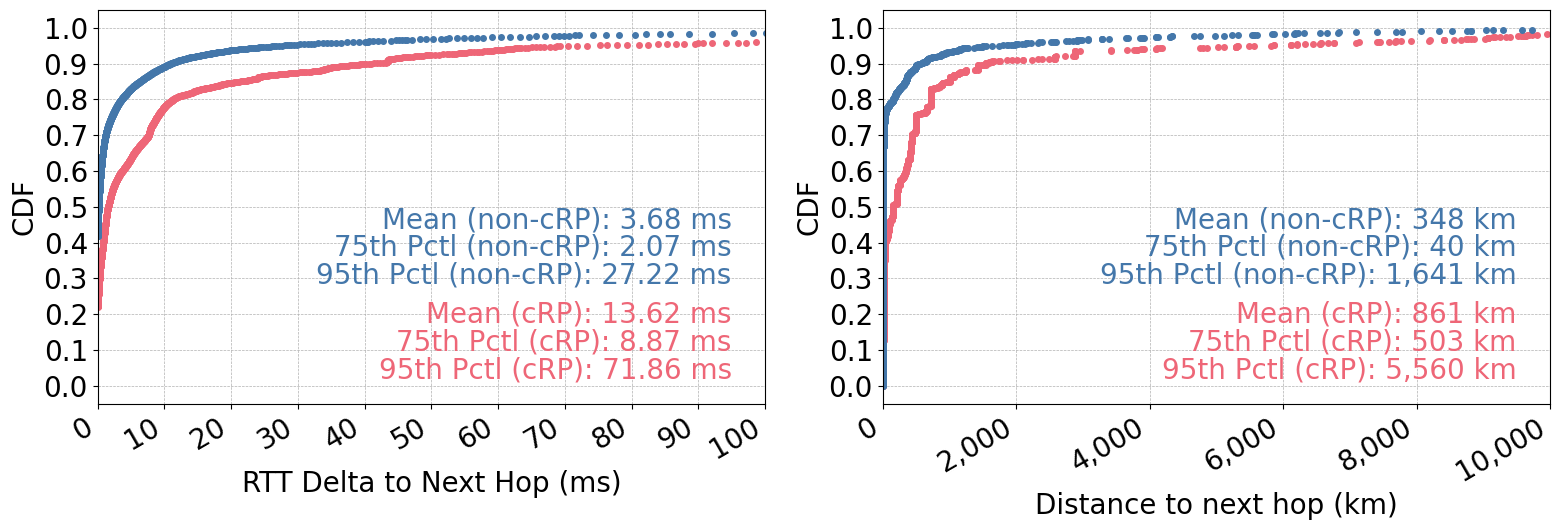

In [32]:
sample_size = 2_000

cb_safe_colors = {
    'blue':  '#4477AA',
    'green': '#228833',
    'red':   '#EE6677',
    'orange': '#FFA500',
}

indexes_to_plot = {
    "cRP": (fcrp_indexes, cb_safe_colors['red'], 'o'),
    "non-cRP": (non_fcrp_indexes, cb_safe_colors['blue'], 'o'),
}

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# plot rtt deltas (left subplot)
y_text_offset_1 = 0.05  # text label offset

for label, (idx, color, marker) in indexes_to_plot.items():
    latencies = traceroutes_df.loc[idx]['rtt_delta_next_hop'].dropna()
    # latencies = latencies[latencies > 0]

    x_full, y_full = get_cdf_data(latencies)
    x_down, y_down = downsample_cdf(x_full, y_full, num_points=sample_size)
    ax1.plot(x_down, y_down, marker=marker, linestyle='none', label=label, markersize=4, color=color)

    # statistics
    mean_latency = np.mean(latencies)
    p75_latency = latencies.quantile(0.75)
    p95_latency = latencies.quantile(0.95)

    # ax1.axvline(x=p75_latency, color=color, linestyle=':')
    # ax1.axvline(x=p95_latency, color=color, linestyle=':')

    ax1.text(0.95, y_text_offset_1, f'95th Pctl ({label}): {p95_latency:.2f} ms',
             transform=ax1.transAxes, color=color, fontsize=20,
             ha='right', va='bottom')
    y_text_offset_1 += 0.07

    ax1.text(0.95, y_text_offset_1, f'75th Pctl ({label}): {p75_latency:.2f} ms',
             transform=ax1.transAxes, color=color, fontsize=20,
             ha='right', va='bottom')
    y_text_offset_1 += 0.07

    ax1.text(0.95, y_text_offset_1, f'Mean ({label}): {mean_latency:.2f} ms',
             transform=ax1.transAxes, color=color, fontsize=20,
             ha='right', va='bottom')
    y_text_offset_1 += 0.07

    # Add a little extra space before the next group of text
    y_text_offset_1 += 0.03


ax1.set_xlabel("RTT Delta to Next Hop (ms)")
ax1.set_ylabel("CDF")
# ax1.set_title("CDF of RTT Delta to Next Hop", fontsize=16)
ax1.grid(True, which="both", linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax1.set_xlim(left=0, right=100)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(0.1))

# ax1.set_xscale('log')

# plot distances (right subplot)
y_text_offset_2 = 0.05  # text label offset

for label, (idx, color, marker) in indexes_to_plot.items():
    distances = traceroutes_df.loc[idx]['distance_to_next_geoloc_hop_km'].dropna()

    x_full, y_full = get_cdf_data(distances)
    x_down, y_down = downsample_cdf(x_full, y_full, num_points=sample_size)

    ax2.plot(x_down, y_down, marker=marker, linestyle='none', label=label, markersize=4, color=color)

    # statistics
    mean_distance = int(np.mean(distances))
    p75_distance = int(distances.quantile(0.75))
    p95_distance = int(distances.quantile(0.95))

    # ax2.axvline(x=p75_distance, color=color, linestyle=':')
    # ax2.axvline(x=p95_distance, color=color, linestyle=':')

    ax2.text(0.95, y_text_offset_2, f'95th Pctl ({label}): {p95_distance:,} km',
             transform=ax2.transAxes, color=color, fontsize=20,
             ha='right', va='bottom')
    y_text_offset_2 += 0.07

    ax2.text(0.95, y_text_offset_2, f'75th Pctl ({label}): {p75_distance:,} km',
             transform=ax2.transAxes, color=color, fontsize=20,
             ha='right', va='bottom')
    y_text_offset_2 += 0.07

    ax2.text(0.95, y_text_offset_2, f'Mean ({label}): {mean_distance:,} km',
             transform=ax2.transAxes, color=color, fontsize=20,
             ha='right', va='bottom')
    y_text_offset_2 += 0.07

    # Add a little extra space before the next group of text
    y_text_offset_2 += 0.03


ax2.set_xlabel("Distance to next hop (km)")
ax2.set_ylabel("CDF")

ax2.xaxis.set_major_formatter(mticker.FuncFormatter(thousands_formatter))
ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
# ax2.set_title("CDF of Distance to Next Hop", fontsize=16)
ax2.grid(True, which="both", linestyle='--', linewidth=0.5)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2_000))
ax2.set_xlim(left=0, right=10_000)
# ax2.set_xscale('log')

# tilt labels
plt.setp(ax1.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")

# shared legend for the line types
# handles, labels = ax1.get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, markerscale=5)

# adjust layout to prevent titles/labels from overlapping and make room for the legend
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("./plots/cdf_comparison.pdf", bbox_inches='tight')

plt.show()

In [33]:
# classify traceroutes with and without candidate RP links

# get the traceroute identifier keys (tx_hostname, dst) pairs
fcrp_keys_index = pd.MultiIndex.from_frame(
    fcrp_links[['tx_hostname', 'dst']].drop_duplicates()
)

# get the indices for each traceroute identifier
traceroutes_keys_index = pd.MultiIndex.from_frame(
    traceroutes_df[['tx_hostname', 'dst']]
)

# check whether the traceroute identifier is part of the candidate RP set
traceroutes_df['is_fcrp'] = traceroutes_keys_index.isin(fcrp_keys_index)

In [34]:
def calculate_delta_cdf(df, col1, col2, downsample=False):
    """
    Calculates the CDF for the delta between two columns in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        col1 (str): The name of the first column for the delta (e.g., 'dist_to_phop').
        col2 (str): The name of the second column for the delta (e.g., 'dist_nearest_site').
        downsample (bool): If True, downsamples the CDF data for cleaner plotting.

    Returns:
        tuple: A tuple containing (x_cdf, y_cdf) for the delta's CDF.
               Returns (np.array([]), np.array([])) if the input DataFrame is empty.
    """
    # get the delta
    delta = df[col1] - df[col2]

    # print optimal and sub-optimal traceroutes
    print(f"Optimal traceroutes {delta[delta <= 100].count()}")
    print(f"Sub-optimal traceroutes {delta[delta > 100].count()}")

    # compute CDF
    x, y = get_cdf_data(delta)

    # downsample
    if downsample:
        x, y = downsample_cdf(x, y)

    return x, y

In [35]:
# get the CDF sub-optimal/optimal routing metrics for all, CRP, and non-CRP traceroutes

# all traceroutes
all_links_firsts = traceroutes_df.groupby(['tx_hostname', 'dst_prefix']).first()
print(f"Found {len(all_links_firsts)} unique 'all' traceroutes.")

# traceroutes with candidate RPs
fcrp_links_firsts = fcrp_links.groupby(['tx_hostname', 'dst_prefix']).first()
print(f"Found {len(fcrp_links_firsts)} unique 'FCR-P' traceroutes.")

# traceroutes without candidate RPs
non_fcrp_links_firsts = traceroutes_df[~traceroutes_df['is_fcrp']].groupby(['tx_hostname', 'dst_prefix']).first()

print(f"Found {len(non_fcrp_links_firsts)} unique 'non-FCR-P' traceroutes.")


print("\nCalculating CDFs...")

print('All traceorutes')
x_all, y_all = calculate_delta_cdf(all_links_firsts, 'dist_to_phop', 'dist_nearest_site')
print('Candidate RP traceroutes')
x_fcrp, y_fcrp = calculate_delta_cdf(fcrp_links_firsts, 'dist_to_phop', 'dist_nearest_site')
print('non RP traceroutes')
x_non_fcrp, y_non_fcrp = calculate_delta_cdf(non_fcrp_links_firsts, 'dist_to_phop', 'dist_nearest_site')

Found 3353799 unique 'all' traceroutes.
Found 322943 unique 'FCR-P' traceroutes.
Found 3030856 unique 'non-FCR-P' traceroutes.

Calculating CDFs...
All traceorutes
Optimal traceroutes 2302489
Sub-optimal traceroutes 854589
Candidate RP traceroutes
Optimal traceroutes 204865
Sub-optimal traceroutes 105632
non RP traceroutes
Optimal traceroutes 2097624
Sub-optimal traceroutes 748957


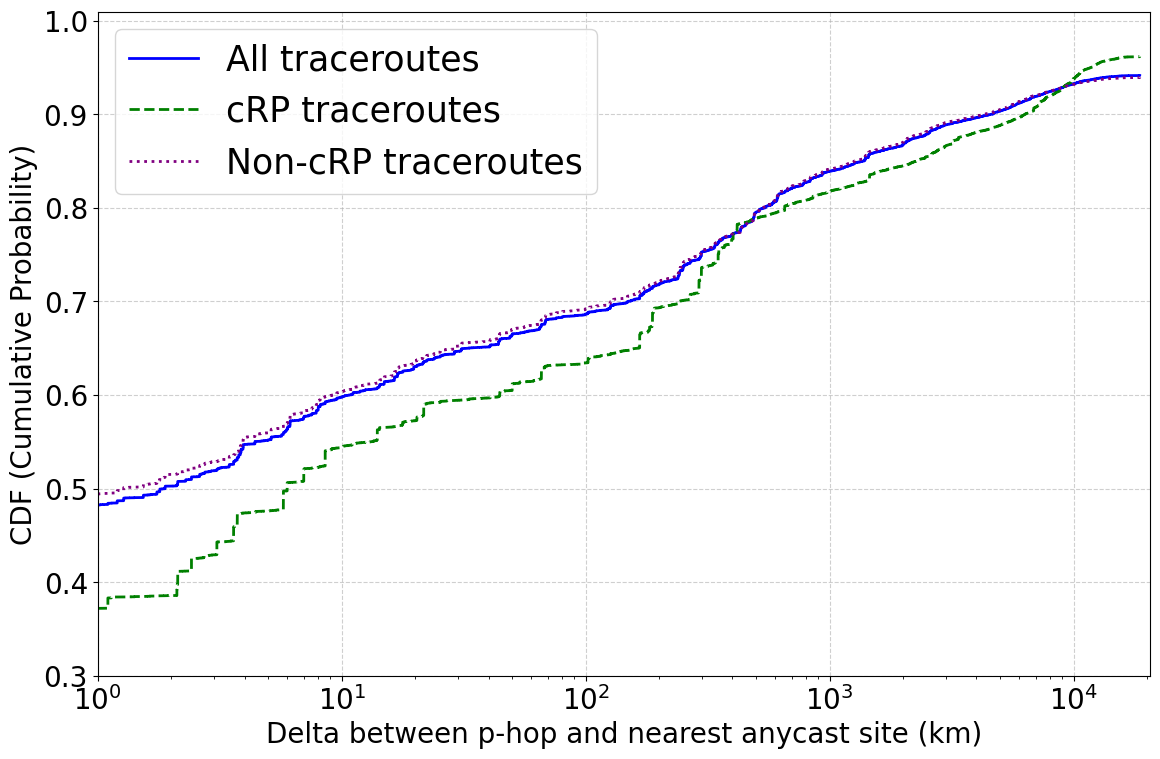

In [36]:
plot_data = {
    'All traceroutes': {
        'x': x_all,
        'y': y_all,
        'color': 'blue',
        'linestyle': '-'
    },
    'cRP traceroutes': {
        'x': x_fcrp,
        'y': y_fcrp,
        'color': 'green',
        'linestyle': '--'
    },
    'Non-cRP traceroutes': {
        'x': x_non_fcrp,
        'y': y_non_fcrp,
        'color': 'purple',
        'linestyle': ':'
    }
}

plt.figure(figsize=(12, 8))

# Loop through the organized data and plot each CDF
for label, data in plot_data.items():
    plt.plot(data['x'], data['y'],
             label=label,
             color=data['color'],
             linestyle=data['linestyle'],
             drawstyle='steps-post',
             linewidth=2,
             )

plt.xlabel("Delta between p-hop and nearest anycast site (km)", fontsize=20)
plt.ylabel("CDF (Cumulative Probability)", fontsize=20)
plt.legend(loc='best', fontsize=25)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(left=1) # Start at 1km to avoid log(0) issues
plt.xscale('log')

plt.yticks(np.arange(0, 1.05, 0.10))
plt.ylim(bottom=0)

# # sub-optimal threshold
# plt.axvline(x=100, color='red', linestyle='--', linewidth=1.5, alpha=0.9)

# # Text annotation for the vertical line
# plt.text(100, 0.5, '100 km Delta',
#          ha='right', va='center', rotation=90, color='red',
#          bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3'))

# plt.text(60, 0.4, 'Optimal site reached', ha='right', va='center', rotation=0, color='red')
# plt.text(120, 0.6, 'Sub-optimal site reached', ha='left', va='center', rotation=0, color='red')

plt.ylim(bottom=0.3)

plt.tight_layout()
plt.savefig('./plots/comparison_cdf_distances.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [39]:
grouped_traceroutes = traceroutes_df.groupby(['tx_hostname', 'dst'])
# grouped_traceroutes = traceroutes_df[traceroutes_df['is_fcrp']].groupby(['tx_hostname', 'dst'])
# grouped_traceroutes = traceroutes_df[~traceroutes_df['is_fcrp']].groupby(['tx_hostname', 'dst'])

summary_df = grouped_traceroutes.agg(
    destination_rtt=('pop_rtt', 'first'),
    distance_to_phop=('dist_to_phop', 'first'),
    inter_hop_distance_sum=('distance_to_next_geoloc_hop_km', 'sum'), # Renamed for clarity
    encounters_rp=('is_fcrp', 'first'),

    # get distance from VP to first geolocated hop (to include it in the sum)
    vp_lat=('vp_lat', 'first'),
    vp_lon=('vp_lon', 'first'),
    first_hop_lat=('hop_lat', 'first'), # 'first' will get the first non-NaN hop lat
    first_hop_lon=('hop_lon', 'first'),
).reset_index()

# calculate distance from VP to first hop
summary_df['dist_vp_to_first_hop'] = summary_df.apply(
    lambda row: haversine(
        row['vp_lat'], row['vp_lon'],
        row['first_hop_lat'], row['first_hop_lon']
    ),
    axis=1
)

# add
summary_df['path_length_km'] = (
    summary_df['inter_hop_distance_sum'] + summary_df['dist_vp_to_first_hop'].fillna(0)
)

summary_df.drop(columns=[
    'inter_hop_distance_sum',
    'dist_vp_to_first_hop',
    'vp_lat', 'vp_lon',
    'first_hop_lat', 'first_hop_lon'
], inplace=True)

summary_df = summary_df.reset_index()

summary_df = summary_df.rename(columns={
    'destination_rtt': 'pop_rtt_ms',
    'distance_to_phop': 'dist_to_phop_km',
    'total_distance_traveled_km': 'path_length_km'
})


summary_df.head()

,index,tx_hostname,dst,pop_rtt_ms,dist_to_phop_km,encounters_rp,path_length_km
0,0,abz2-uk,1.1.1.0,13.729,408.086189,False,490.381207
1,1,abz2-uk,1.10.10.10,132.708,8329.185570,False,9024.041845
2,2,abz2-uk,1.12.0.1,25.568,1054.217133,False,1328.295086
3,3,abz2-uk,1.12.12.12,25.344,1054.217133,False,1328.295086
4,4,abz2-uk,1.12.13.50,25.461,1054.217133,False,1328.295086


In [40]:
# encountering RP

len(summary_df[summary_df['encounters_rp']])

322943

In [41]:
# not encounter RP

len(summary_df[~summary_df['encounters_rp']])


3030856

In [42]:
summary_df['pop_rtt_s'] = summary_df['pop_rtt_ms'] / 1000.0
summary_df['max_dist_km'] = (SPEED_IN_FIBRE * summary_df['pop_rtt_s']) / 2.0

In [ ]:
summary_df = summary_df[['tx_hostname', 'dst', 'max_dist_km', 'dist_to_phop_km', 'path_length_km', 'encounters_rp']]

In [ ]:
summary_df.head()

In [ ]:
# show top 10 highest path_length_km
summary_df.sort_values(by='path_length_km', ascending=False).head(10)

In [ ]:
traceroutes_df[(traceroutes_df['dst'] == '104.44.14.118') & (traceroutes_df['tx_hostname'] == 'mru-mu')]

In [ ]:
summary_df.describe()

In [ ]:

destination_dist_col = 'dist_to_phop_km'

summary_df['detour_ratio'] = summary_df['path_length_km'] / summary_df[destination_dist_col].replace(0, np.nan)
summary_df.dropna(subset=['detour_ratio'], inplace=True)

# sample size
# n_per_group = 25_000
n_per_group = 5_000

df_with_rp = summary_df[summary_df['encounters_rp'] == True]
df_without_rp = summary_df[summary_df['encounters_rp'] == False]

n_sample_with_rp = min(n_per_group, len(df_with_rp))
n_sample_without_rp = min(n_per_group, len(df_without_rp))

if n_sample_with_rp < n_per_group:
    print(f"Warning: Only found {n_sample_with_rp} data points with 'encounters_rp=True', less than the desired {n_per_group}.")
if n_sample_without_rp < n_per_group:
    print(f"Warning: Only found {n_sample_without_rp} data points with 'encounters_rp=False', less than the desired {n_per_group}.")

# Take the random samples
sample_with_rp = df_with_rp.sample(n=n_sample_with_rp, random_state=42)
sample_without_rp = df_without_rp.sample(n=n_sample_without_rp, random_state=42)


fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    sample_without_rp[destination_dist_col],
    sample_without_rp['path_length_km'],
    color='#E69F00',
    s=50,
    alpha=0.9,
    marker='x',
    label='non-cRP traceroutes',
    zorder=3
)

ax.scatter(
    sample_with_rp[destination_dist_col],
    sample_with_rp['path_length_km'],
    s=120,
    facecolors='none',
    edgecolors='#56B4E9',
    linewidth=1.0,
    label='cRP traceroutes',
    zorder=2
)

combined_sample = pd.concat([sample_with_rp, sample_without_rp])
lim_min = min(combined_sample[destination_dist_col].min(), combined_sample['path_length_km'].min())
lim_max = max(combined_sample[destination_dist_col].quantile(1.0), combined_sample['path_length_km'].quantile(0.95))
# plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label='Path length == Distance to p-hop')

x_range = [lim_min, lim_max]

plt.plot(x_range, [x for x in x_range],
         color='green',
         linestyle='-',
         label='Detour Ratio = 1')

plt.plot(x_range, [2 * x for x in x_range],
         color='orange',
         linestyle='-',
         label='Detour Ratio = 2')

plt.plot(x_range, [4 * x for x in x_range],
         color='red',
         linestyle='-',
         label='Detour Ratio = 4')


plt.xlabel(f'Distance to p-hop (km)')
plt.ylabel('Inferred path length (km)')

plt.ylim(top=50_000)


### legend

# plt.legend(loc='lower right')
all_handles, all_labels = ax.get_legend_handles_labels()

marker_handles = []
marker_labels = []
line_handles = []
line_labels = []

for handle, label in zip(all_handles, all_labels):
    if 'traceroute' in label:
        marker_handles.append(handle)
        marker_labels.append(label)
    elif 'Detour Ratio' in label:
        line_handles.append(handle)
        line_labels.append(label)

legend1 = ax.legend(line_handles, line_labels, loc='lower right')
ax.add_artist(legend1)

legend2 = ax.legend(marker_handles, marker_labels, loc='upper left', markerscale=1.5)

plt.grid(True, linestyle='--', alpha=0.7)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands_formatter))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands_formatter))

plt.xlim(left=1)
plt.ylim(bottom=1)

# save fig
plt.savefig('path_length_vs_distance_to_phop_stratified.pdf', bbox_inches='tight', pad_inches=0)

plt.show()

In [ ]:
summary_df[summary_df['detour_ratio'] > 4]

In [ ]:
print(f"Found {len(summary_df[summary_df['detour_ratio'] > 4])} traceroutes with a detour ratio higher than 4 of which {len(summary_df[(summary_df['detour_ratio'] > 4) & (summary_df['encounters_rp'])])} encounter RP")

In [ ]:
df_rp = summary_df[summary_df['encounters_rp'] == True]
df_no_rp = summary_df[summary_df['encounters_rp'] == False]

total_rp = len(df_rp)
total_no_rp = len(df_no_rp)

thresholds = range(2, 11)
results_data = []

for t in thresholds:
    # Count how many in each group exceed the current threshold
    count_rp_gt_t = len(df_rp[df_rp['detour_ratio'] > t])
    count_no_rp_gt_t = len(df_no_rp[df_no_rp['detour_ratio'] > t])

    # Calculate the percentage for each group
    percent_rp = (count_rp_gt_t / total_rp) * 100
    percent_no_rp = (count_no_rp_gt_t / total_no_rp) * 100

    # Store the results for this threshold
    results_data.append({
        'Detour ratio': f'> {t}',
        '% of Non-cRP': percent_no_rp,
        '% of cRP': percent_rp
    })

results_df = pd.DataFrame(results_data)
results_df.set_index('Detour ratio', inplace=True)

results_df['% of Non-cRP'] = results_df['% of Non-cRP'].map('{:.2f}%'.format)
results_df['% of cRP'] = results_df['% of cRP'].map('{:.2f}%'.format)

results_df

In [ ]:
# show top 10 highest detours
summary_df.sort_values(by='detour_ratio', ascending=False).head(10)


In [ ]:
fcrp_links['hop_sub_region']

In [ ]:
# get next region for each hop
traceroutes_df['next_hop_sub_region'] = traceroutes_df.groupby(['tx_hostname', 'dst'])['hop_sub_region'].shift(-1)


In [ ]:
# get the first hops of all candidate RP links
first_hops_of_crp = traceroutes_df.loc[fcrp_indexes]

first_hops_of_crp[['hop_sub_region', 'next_hop_sub_region']]

In [ ]:
first_hops_of_crp['next_hop_sub_region'].value_counts().head(10)

In [ ]:
first_hops_of_crp['hop_sub_region'].value_counts().head(10)

In [ ]:
first_hops_of_crp.groupby(['hop_sub_region', 'next_hop_sub_region']).size().nlargest(10)

In [ ]:
inter_region_mask = first_hops_of_crp['hop_sub_region'] != first_hops_of_crp['next_hop_sub_region']

# Step 2: Apply the mask to create a new DataFrame of only inter-region links.
inter_region_links = first_hops_of_crp[inter_region_mask]

# Step 3: Perform the groupby and count on this filtered DataFrame.
top_10_inter_region_links = inter_region_links.groupby(
    ['hop_sub_region', 'next_hop_sub_region']
).size().nlargest(10)

print("--- Top 10 Inter-Region Links (Hop != Next-Hop) ---")
top_10_inter_region_links

In [ ]:
# calculate region statistics for unique IP links

# Isolate the relevant columns for clarity and efficiency
link_data = first_hops_of_crp[['hop_addr', 'next_hop_addr', 'hop_sub_region', 'next_hop_sub_region']]

# Find all unique IP-level links. Each row in this new DataFrame is one distinct link.
unique_ip_links = link_data.drop_duplicates(subset=['hop_addr', 'next_hop_addr'])

print(f"Original number of rows: {len(first_hops_of_crp)}")
print(f"Number of unique IP-level links: {len(unique_ip_links)}")

In [ ]:
# top 10 regions where RP originates
unique_ip_links['hop_sub_region'].value_counts().head(12)


In [ ]:
# top 10 regions where RP ends
unique_ip_links['next_hop_sub_region'].value_counts().head(12)


In [ ]:
unique_ip_links['hop_sub_region'].nunique() # 12 regions total

In [ ]:
hop_counts = unique_ip_links['hop_sub_region'].value_counts().head(12)
next_hop_counts = unique_ip_links['next_hop_sub_region'].value_counts().head(12)

# Combine into a single DataFrame
combined_df = pd.DataFrame({
    'RP start': hop_counts,
    'RP end': next_hop_counts
})

combined_df['pct_difference'] = ((combined_df['RP end'] - combined_df['RP start']) / combined_df['RP start']) * 100


combined_df

In [ ]:
# plot most often region links

unique_ip_links.groupby(['hop_sub_region', 'next_hop_sub_region']).size().nlargest(10)


In [ ]:
inter_region_mask = unique_ip_links['hop_sub_region'] != unique_ip_links['next_hop_sub_region']

inter_region_links = unique_ip_links[inter_region_mask]

top_10_inter_region_links = inter_region_links.groupby(
    ['hop_sub_region', 'next_hop_sub_region']
).size().nlargest(10)

print("--- Top 10 Inter-Region Links (Hop != Next-Hop) ---")
top_10_inter_region_links